# Labeled Sample Spectral Analysis

This notebook analyzes labeled protein samples with expected peaks at:
- **Label peak 1**: ~315 nm
- **Label peak 2**: ~412 nm

## Key Features
- Optimized for labeled chromophores
- Tracks peak intensities and positions over time
- Allows small peak shifts to track environmental changes
- Calculates label ratios and stoichiometry

## Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lmfit.models import GaussianModel, LinearModel
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

%matplotlib inline

## Load Data

In [7]:
import os
from pathlib import Path

# Create output directories
output_base = Path('spectral_analysis_output')
output_base.mkdir(exist_ok=True)

labeled_output = output_base / 'DTNB_Dose_labeled'
labeled_output.mkdir(exist_ok=True)

# Load labeled data files only (DTNB_Dose)
datasets = {}

dtnb_path = Path('DTNB_Dose')
for csv_file in sorted(dtnb_path.glob('final_pyspec_*.csv')):
    transmission = csv_file.stem.split('_')[-1]  # Extract percentage (e.g., '5', '25', etc.)
    key = f'DTNB_{transmission}%'
    data = pd.read_csv(csv_file, index_col=0)
    datasets[key] = {
        'data': data,
        'label': 'Labeled (DTNB)',
        'transmission': transmission,
        'output_dir': labeled_output / f'DTNB_{transmission}%'
    }
    datasets[key]['output_dir'].mkdir(exist_ok=True)
    print(f"Loaded {key}: shape {data.shape}")

print(f"\nTotal datasets loaded: {len(datasets)}")
print(f"Output directories created at: {output_base.absolute()}")


Loaded DTNB_100%: shape (1600, 1000)
Loaded DTNB_25%: shape (1600, 1000)
Loaded DTNB_5%: shape (1600, 1000)
Loaded DTNB_50%: shape (1600, 1000)

Total datasets loaded: 4
Output directories created at: /workspaces/py_spec/spectral_analysis_output


## Filter to Relevant Wavelength Range

Focus on 280-450 nm to capture both label peaks:

In [8]:
# Filter to label-relevant wavelengths for all datasets
filtered_datasets = {}

for dataset_name, dataset_info in datasets.items():
    data = dataset_info['data']
    wavelengths = data.index.astype(float)
    data_filtered = data[(wavelengths >= 280) & (wavelengths <= 450)]
    
    filtered_datasets[dataset_name] = {
        **dataset_info,
        'data_filtered': data_filtered
    }
    
    print(f"{dataset_name}:")
    print(f"  Data shape: {data_filtered.shape}")
    print(f"  Wavelength range: {data_filtered.index.astype(float).min():.1f} - {data_filtered.index.astype(float).max():.1f} nm")
    print(f"  Time points: {len(data_filtered.columns)}")


DTNB_100%:
  Data shape: (495, 1000)
  Wavelength range: 280.1 - 449.9 nm
  Time points: 1000
DTNB_25%:
  Data shape: (495, 1000)
  Wavelength range: 280.1 - 449.9 nm
  Time points: 1000
DTNB_5%:
  Data shape: (495, 1000)
  Wavelength range: 280.1 - 449.9 nm
  Time points: 1000
DTNB_50%:
  Data shape: (495, 1000)
  Wavelength range: 280.1 - 449.9 nm
  Time points: 1000


## Peak Detection Helper Function

In [3]:
def detect_label_peaks(x, y, expected_positions=[315, 412], prominence_factor=0.05):
    """
    Detect label peaks in spectrum.
    
    Parameters:
    -----------
    x : array
        Wavelength values
    y : array
        Absorbance values
    expected_positions : list
        Expected peak wavelengths [315, 412]
    prominence_factor : float
        Minimum prominence as fraction of max absorbance
    
    Returns:
    --------
    dict : Dictionary with peak positions, amplitudes, and widths
    """
    # Smooth the data slightly
    y_smooth = gaussian_filter1d(y, sigma=1)
    
    # Find peaks
    prominence = prominence_factor * (y_smooth.max() - y_smooth.min())
    peaks, properties = find_peaks(y_smooth, prominence=prominence, width=1)
    
    if len(peaks) == 0:
        # If no peaks found, use expected positions
        return {pos: {'center': pos, 'amplitude': 0.1, 'sigma': 10} 
                for pos in expected_positions}
    
    # Match detected peaks to expected positions
    peak_info = {}
    for expected_pos in expected_positions:
        peak_wavelengths = x[peaks]
        distances = np.abs(peak_wavelengths - expected_pos)
        
        if len(distances) > 0:
            closest_idx = np.argmin(distances)
            if distances[closest_idx] < 30:  # Within 30 nm
                peak_idx = peaks[closest_idx]
                peak_info[expected_pos] = {
                    'center': x[peak_idx],
                    'amplitude': y[peak_idx],
                    'sigma': properties['widths'][closest_idx] * (x[1] - x[0])
                }
            else:
                # Use expected position
                peak_info[expected_pos] = {
                    'center': expected_pos,
                    'amplitude': np.interp(expected_pos, x, y),
                    'sigma': 10
                }
        else:
            peak_info[expected_pos] = {
                'center': expected_pos,
                'amplitude': 0.1,
                'sigma': 10
            }
    
    return peak_info

## Define Fitting Model for Labeled Sample

Model components:
- **Peak 1**: Label at ~315 nm - center allowed to vary ±15 nm
- **Peak 2**: Label at ~412 nm - center allowed to vary ±10 nm
- **Baseline**: Linear baseline

In [6]:
def create_label_model(x, y, previous_fit=None):
    """
    Create model for labeled sample with two label peaks.
    ALWAYS detects peaks on current spectrum for adaptive fitting.
    
    Parameters:
    -----------
    x : array
        Wavelength values
    y : array
        Absorbance values
    previous_fit : lmfit.ModelResult or None
        Previous fit result (used for reference but not constraints)
    
    Returns:
    --------
    model : lmfit Model
        Combined model
    params : lmfit.Parameters
        Initial parameters
    """
    # ALWAYS detect peaks on the current spectrum
    # This allows tracking of peak shifts and evolution over time
    peak_info = detect_label_peaks(x, y, expected_positions=[315, 412])
    
    # Peak 1: Label at ~315 nm
    peak1 = GaussianModel(prefix='label315_')
    info = peak_info[315]
    params1 = peak1.make_params(
        amplitude=dict(value=info['amplitude'], min=0),
        center=dict(value=info['center'], min=300, max=330),  # Allow ±15 nm shift
        sigma=dict(value=max(5, info['sigma']), min=3, max=20)
    )
    
    # Peak 2: Label at ~412 nm
    peak2 = GaussianModel(prefix='label412_')
    info = peak_info[412]
    params2 = peak2.make_params(
        amplitude=dict(value=info['amplitude'], min=0),
        center=dict(value=info['center'], min=402, max=422),  # Allow ±10 nm shift
        sigma=dict(value=max(5, info['sigma']), min=3, max=20)
    )
    
    # Linear baseline
    baseline = LinearModel(prefix='baseline_')
    params_base = baseline.make_params(
        slope=dict(value=0, min=-0.01, max=0.01),
        intercept=dict(value=np.median(y), min=-1, max=2)
    )
    
    # Combine model and parameters
    model = peak1 + peak2 + baseline
    params = params1 + params2 + params_base
    
    return model, params

## Fit All Time Points

In [ ]:
# Storage for fit results
all_fit_results = {}

for dataset_name, dataset_info in filtered_datasets.items():
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")
    
    data_filtered = dataset_info['data_filtered']
    fit_results = []
    previous_fit = None
    
    # Fit each time point
    for i, time_point in enumerate(data_filtered.columns):
        x = data_filtered.index.values.astype(float)
        y = data_filtered[time_point].values
        
        # Create model
        model, params = create_label_model(x, y, previous_fit)
        
        # Fit
        try:
            result = model.fit(y, params, x=x, method='leastsq', max_nfev=10000)
            fit_results.append(result)
            previous_fit = result
        except Exception as e:
            print(f"Warning: Fit failed for time point {time_point}: {e}")
            fit_results.append(None)
        
        if (i + 1) % 10 == 0:
            print(f"  Fitted {i + 1}/{len(data_filtered.columns)} time points")
    
    all_fit_results[dataset_name] = fit_results
    print(f"Completed fitting {len([f for f in fit_results if f is not None])}/{len(data_filtered.columns)} time points")



Processing: DTNB_100%
  Fitted 10/1000 time points
  Fitted 20/1000 time points
  Fitted 30/1000 time points
  Fitted 40/1000 time points
  Fitted 50/1000 time points
  Fitted 60/1000 time points
  Fitted 70/1000 time points
  Fitted 80/1000 time points
  Fitted 90/1000 time points
  Fitted 100/1000 time points
  Fitted 110/1000 time points


## Visualize First Fit

In [14]:
# Visualize first fit for each dataset and save
for dataset_name, fit_results in all_fit_results.items():
    dataset_info = filtered_datasets[dataset_name]
    output_dir = dataset_info['output_dir']
    data_filtered = dataset_info['data_filtered']
    
    if fit_results[0] is not None:
        result = fit_results[0]
        time_point = data_filtered.columns[0]
        x = data_filtered.index.values.astype(float)
        y = data_filtered[time_point].values
        comps = result.eval_components(x=x)
        
        plt.figure(figsize=(12, 7))
        plt.scatter(x, y, label=f'Data ({time_point})', s=10, alpha=0.6, color='black')
        plt.plot(x, result.best_fit, label='Best Fit', color='red', linewidth=2.5)
        plt.plot(x, comps['label315_'], label='Label 315nm', linestyle='--', linewidth=2, color='#ff7f0e')
        plt.plot(x, comps['label412_'], label='Label 412nm', linestyle='--', linewidth=2, color='#2ca02c')
        plt.plot(x, comps['baseline_'], label='Baseline', linestyle=':', linewidth=1.5, color='gray')
        
        # Mark peak positions
        label315_center = result.params['label315_center'].value
        label412_center = result.params['label412_center'].value
        plt.axvline(label315_center, color='#ff7f0e', linestyle=':', alpha=0.5)
        plt.axvline(label412_center, color='#2ca02c', linestyle=':', alpha=0.5)
        
        plt.xlabel('Wavelength (nm)', fontsize=12)
        plt.ylabel('Absorbance', fontsize=12)
        plt.title(f'{dataset_name} - First Timepoint\n315nm: {label315_center:.1f} nm, 412nm: {label412_center:.1f} nm', 
                  fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save plot
        output_file = output_dir / f'01_first_fit.png'
        plt.savefig(output_file, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"{dataset_name} - First fit saved to {output_file}")
        print(f"  Reduced χ²: {result.redchi:.6f}")
        print(f"  R²: {1 - result.residual.var() / np.var(y):.6f}")


## Extract Peak Parameters Over Time

In [15]:
# Extract parameters for all datasets
all_parameters = {}

for dataset_name, fit_results in all_fit_results.items():
    dataset_info = filtered_datasets[dataset_name]
    data_filtered = dataset_info['data_filtered']
    
    times = data_filtered.columns.to_list()
    valid_fits = [f for f in fit_results if f is not None]
    valid_indices = [i for i, f in enumerate(fit_results) if f is not None]
    valid_times = [times[i] for i in valid_indices]
    
    if len(valid_fits) > 0:
        label315_centers = [fit.params['label315_center'].value for fit in valid_fits]
        label315_amps = [fit.params['label315_amplitude'].value for fit in valid_fits]
        label315_widths = [fit.params['label315_sigma'].value for fit in valid_fits]
        
        label412_centers = [fit.params['label412_center'].value for fit in valid_fits]
        label412_amps = [fit.params['label412_amplitude'].value for fit in valid_fits]
        label412_widths = [fit.params['label412_sigma'].value for fit in valid_fits]
        
        # Convert times to numeric
        try:
            times_numeric = [float(str(t).replace('s', '')) if isinstance(t, str) else float(t) for t in valid_times]
            time_label = 'Time (s)'
        except (ValueError, TypeError, AttributeError):
            times_numeric = list(range(len(valid_times)))
            time_label = 'Time Point'
        
        all_parameters[dataset_name] = {
            'times': valid_times,
            'times_numeric': times_numeric,
            'time_label': time_label,
            'label315_centers': label315_centers,
            'label315_amps': label315_amps,
            'label315_widths': label315_widths,
            'label412_centers': label412_centers,
            'label412_amps': label412_amps,
            'label412_widths': label412_widths,
        }

print(f"Extracted parameters from {len(all_parameters)} datasets")


Extracted parameters from 0 datasets


## Analyze Peak Positions Over Time

In [13]:
# Save peak position plots for each dataset
for dataset_name, params in all_parameters.items():
    output_dir = filtered_datasets[dataset_name]['output_dir']
    times_numeric = params['times_numeric']
    time_label = params['time_label']
    label315_centers = params['label315_centers']
    label315_widths = params['label315_widths']
    label412_centers = params['label412_centers']
    label412_widths = params['label412_widths']
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Label 315 peak position
    ax1.plot(times_numeric, label315_centers, 'o-', color='#ff7f0e', linewidth=2, markersize=6)
    ax1.axhline(315, color='red', linestyle='--', alpha=0.5, label='Expected (315 nm)')
    ax1.fill_between(times_numeric,
                      [c - w for c, w in zip(label315_centers, label315_widths)],
                      [c + w for c, w in zip(label315_centers, label315_widths)],
                      alpha=0.2, color='#ff7f0e', label='±1σ width')
    ax1.set_ylabel('Wavelength (nm)', fontsize=12)
    ax1.set_title(f'{dataset_name} - Label 315nm Peak Position Over Time', fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Label 412 peak position
    ax2.plot(times_numeric, label412_centers, 's-', color='#2ca02c', linewidth=2, markersize=6)
    ax2.axhline(412, color='red', linestyle='--', alpha=0.5, label='Expected (412 nm)')
    ax2.fill_between(times_numeric,
                      [c - w for c, w in zip(label412_centers, label412_widths)],
                      [c + w for c, w in zip(label412_centers, label412_widths)],
                      alpha=0.2, color='#2ca02c', label='±1σ width')
    ax2.set_xlabel(time_label, fontsize=12)
    ax2.set_ylabel('Wavelength (nm)', fontsize=12)
    ax2.set_title(f'{dataset_name} - Label 412nm Peak Position Over Time', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    output_file = output_dir / f'02_peak_positions.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"{dataset_name}")
    print(f"  Label 315: {np.min(label315_centers):.2f} - {np.max(label315_centers):.2f} nm (Δ = {np.max(label315_centers) - np.min(label315_centers):.2f} nm)")
    print(f"  Label 412: {np.min(label412_centers):.2f} - {np.max(label412_centers):.2f} nm (Δ = {np.max(label412_centers) - np.min(label412_centers):.2f} nm)")
    print(f"  Saved to {output_file}")


DTNB_100%
  Label 315: 300.27 - 330.00 nm (Δ = 29.73 nm)
  Label 412: 402.00 - 422.00 nm (Δ = 20.00 nm)
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/02_peak_positions.png
DTNB_25%
  Label 315: 303.42 - 330.00 nm (Δ = 26.58 nm)
  Label 412: 402.00 - 422.00 nm (Δ = 20.00 nm)
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/02_peak_positions.png
DTNB_5%
  Label 315: 300.00 - 330.00 nm (Δ = 30.00 nm)
  Label 412: 402.00 - 422.00 nm (Δ = 20.00 nm)
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/02_peak_positions.png
DTNB_50%
  Label 315: 304.49 - 330.00 nm (Δ = 25.51 nm)
  Label 412: 402.00 - 422.00 nm (Δ = 20.00 nm)
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_50%/02_peak_positions.png


## Analyze Peak Amplitudes (Label Concentrations)

In [14]:
# Save peak amplitude plots for each dataset
for dataset_name, params in all_parameters.items():
    output_dir = filtered_datasets[dataset_name]['output_dir']
    times_numeric = params['times_numeric']
    time_label = params['time_label']
    label315_amps = params['label315_amps']
    label412_amps = params['label412_amps']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Label 315 amplitude
    axes[0].plot(times_numeric, label315_amps, 'o-', color='#ff7f0e', linewidth=2, markersize=6)
    axes[0].set_xlabel(time_label, fontsize=12)
    axes[0].set_ylabel('Amplitude', fontsize=12)
    axes[0].set_title(f'{dataset_name} - Label 315nm Peak Amplitude', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Label 412 amplitude
    axes[1].plot(times_numeric, label412_amps, 's-', color='#2ca02c', linewidth=2, markersize=6)
    axes[1].set_xlabel(time_label, fontsize=12)
    axes[1].set_ylabel('Amplitude', fontsize=12)
    axes[1].set_title(f'{dataset_name} - Label 412nm Peak Amplitude', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save plot
    output_file = output_dir / f'03_peak_amplitudes.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"{dataset_name}")
    print(f"  Label 315 amplitude range: {np.min(label315_amps):.4f} - {np.max(label315_amps):.4f}")
    print(f"  Label 412 amplitude range: {np.min(label412_amps):.4f} - {np.max(label412_amps):.4f}")
    print(f"  Saved to {output_file}")


DTNB_100%
  Label 315 amplitude range: 0.0000 - 26.9625
  Label 412 amplitude range: 0.0000 - 6.3641
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/03_peak_amplitudes.png
DTNB_25%
  Label 315 amplitude range: 0.0123 - 19.1008
  Label 412 amplitude range: 0.0000 - 4.7174
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/03_peak_amplitudes.png
DTNB_5%
  Label 315 amplitude range: 0.0000 - 5.9712
  Label 412 amplitude range: 0.0000 - 0.9137
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/03_peak_amplitudes.png
DTNB_50%
  Label 315 amplitude range: 0.0000 - 26.9625
  Label 412 amplitude range: 0.0000 - 6.3641
  Saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_50%/03_peak_amplitudes.png


## Plot Multiple Time Points

In [15]:
# Plot multiple time points for each dataset and save
for dataset_name, fit_results in all_fit_results.items():
    dataset_info = filtered_datasets[dataset_name]
    output_dir = dataset_info['output_dir']
    data_filtered = dataset_info['data_filtered']
    
    # Plot every Nth spectrum
    n_plots = min(6, len([f for f in fit_results if f is not None]))
    valid_indices = [i for i, f in enumerate(fit_results) if f is not None]
    step = max(1, len(valid_indices) // n_plots)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, i in enumerate(valid_indices[::step][:n_plots]):
        time_point = data_filtered.columns[i]
        result = fit_results[i]
        x = data_filtered.index.values.astype(float)
        y = data_filtered[time_point].values
        
        axes[idx].scatter(x, y, s=5, alpha=0.6, color='black')
        axes[idx].plot(x, result.best_fit, 'r-', linewidth=2)
        axes[idx].set_title(f'Time: {time_point}', fontsize=10)
        axes[idx].set_xlabel('Wavelength (nm)', fontsize=9)
        axes[idx].set_ylabel('Absorbance', fontsize=9)
        axes[idx].grid(True, alpha=0.3)
    
    # Hide unused axes
    for idx in range(len(valid_indices[::step][:n_plots]), n_plots):
        axes[idx].axis('off')
    
    plt.suptitle(f'{dataset_name} - Multiple Time Points', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save plot
    output_file = output_dir / f'04_multiple_timepoints.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"{dataset_name} - Saved {n_plots} time points to {output_file}")


DTNB_100% - Saved 6 time points to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/04_multiple_timepoints.png
DTNB_25% - Saved 6 time points to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/04_multiple_timepoints.png
DTNB_5% - Saved 6 time points to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/04_multiple_timepoints.png
DTNB_50% - Saved 6 time points to spectral_analysis_output/DTNB_Dose_labeled/DTNB_50%/04_multiple_timepoints.png


## Save Results to CSV

In [16]:
# Create results dataframe and save for all datasets
for dataset_name, params in all_parameters.items():
    dataset_info = filtered_datasets[dataset_name]
    output_dir = dataset_info['output_dir']
    
    times_numeric = params['times_numeric']
    label315_centers = params['label315_centers']
    label315_amps = params['label315_amps']
    label315_widths = params['label315_widths']
    label412_centers = params['label412_centers']
    label412_amps = params['label412_amps']
    label412_widths = params['label412_widths']
    
    # Calculate amplitude ratio
    amplitude_ratio = [a315 / a412 if a412 > 0 else 0 for a315, a412 in zip(label315_amps, label412_amps)]
    
    # Create results dataframe
    results_df = pd.DataFrame({
        'time': times_numeric,
        'label315_center': label315_centers,
        'label315_amplitude': label315_amps,
        'label315_width': label315_widths,
        'label412_center': label412_centers,
        'label412_amplitude': label412_amps,
        'label412_width': label412_widths,
        'amplitude_ratio_315_412': amplitude_ratio
    })
    
    # Save to CSV
    csv_file = output_dir / f'{dataset_name}_results.csv'
    results_df.to_csv(csv_file, index=False)
    print(f"{dataset_name} - Results saved to {csv_file}")


DTNB_100% - Results saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/DTNB_100%_results.csv
DTNB_25% - Results saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/DTNB_25%_results.csv
DTNB_5% - Results saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/DTNB_5%_results.csv
DTNB_50% - Results saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_50%/DTNB_50%_results.csv


## Export Detailed Fit Reports

In [17]:
# Write detailed fit reports for all datasets
for dataset_name, fit_results in all_fit_results.items():
    dataset_info = filtered_datasets[dataset_name]
    output_dir = dataset_info['output_dir']
    data_filtered = dataset_info['data_filtered']
    
    report_file = output_dir / f'{dataset_name}_fit_reports.log'
    with open(report_file, 'w') as f:
        for i, (time_point, fit) in enumerate(zip(data_filtered.columns, fit_results)):
            if fit is not None:
                f.write(f'\n{"="*80}\n')
                f.write(f'Time point: {time_point}\n')
                f.write(f'{"="*80}\n')
                f.write(fit.fit_report(min_correl=0.3))
                f.write('\n')
    
    print(f"{dataset_name} - Detailed fit reports saved to {report_file}")


DTNB_100% - Detailed fit reports saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/DTNB_100%_fit_reports.log
DTNB_25% - Detailed fit reports saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/DTNB_25%_fit_reports.log
DTNB_5% - Detailed fit reports saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/DTNB_5%_fit_reports.log
DTNB_50% - Detailed fit reports saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_50%/DTNB_50%_fit_reports.log


## Summary Statistics

In [18]:
# Summary Statistics for all datasets
print("\n" + "="*80)
print("SPECTRAL ANALYSIS SUMMARY")
print("="*80)

for dataset_name, params in all_parameters.items():
    label315_centers = params['label315_centers']
    label315_amps = params['label315_amps']
    label412_centers = params['label412_centers']
    label412_amps = params['label412_amps']
    
    # Calculate amplitude ratio
    amplitude_ratio = [a315 / a412 if a412 > 0 else 0 for a315, a412 in zip(label315_amps, label412_amps)]
    
    print(f"\n{dataset_name}:")
    print(f"  Label 315nm Peak:")
    print(f"    Center range: {np.min(label315_centers):.2f} - {np.max(label315_centers):.2f} nm")
    print(f"    Mean center: {np.mean(label315_centers):.2f} ± {np.std(label315_centers):.2f} nm")
    print(f"    Amplitude range: {np.min(label315_amps):.4f} - {np.max(label315_amps):.4f}")
    print(f"    Mean amplitude: {np.mean(label315_amps):.4f} ± {np.std(label315_amps):.4f}")
    
    print(f"  Label 412nm Peak:")
    print(f"    Center range: {np.min(label412_centers):.2f} - {np.max(label412_centers):.2f} nm")
    print(f"    Mean center: {np.mean(label412_centers):.2f} ± {np.std(label412_centers):.2f} nm")
    print(f"    Amplitude range: {np.min(label412_amps):.4f} - {np.max(label412_amps):.4f}")
    print(f"    Mean amplitude: {np.mean(label412_amps):.4f} ± {np.std(label412_amps):.4f}")
    
    print(f"  Amplitude Ratio (315/412):")
    print(f"    Range: {np.min(amplitude_ratio):.3f} - {np.max(amplitude_ratio):.3f}")
    print(f"    Mean: {np.mean(amplitude_ratio):.3f} ± {np.std(amplitude_ratio):.3f}")

print("\n" + "="*80)



SPECTRAL ANALYSIS SUMMARY

DTNB_100%:
  Label 315nm Peak:
    Center range: 300.27 - 330.00 nm
    Mean center: 324.90 ± 4.56 nm
    Amplitude range: 0.0000 - 26.9625
    Mean amplitude: 8.6750 ± 5.7542
  Label 412nm Peak:
    Center range: 402.00 - 422.00 nm
    Mean center: 406.42 ± 6.20 nm
    Amplitude range: 0.0000 - 6.3641
    Mean amplitude: 0.6473 ± 1.0690
  Amplitude Ratio (315/412):
    Range: 0.000 - 27681213373606588.000
    Mean: 86947208990863.531 ± 1188402706269571.250

DTNB_25%:
  Label 315nm Peak:
    Center range: 303.42 - 330.00 nm
    Mean center: 325.77 ± 2.28 nm
    Amplitude range: 0.0123 - 19.1008
    Mean amplitude: 9.6025 ± 2.8108
  Label 412nm Peak:
    Center range: 402.00 - 422.00 nm
    Mean center: 405.55 ± 6.02 nm
    Amplitude range: 0.0000 - 4.7174
    Mean amplitude: 0.7361 ± 0.6427
  Amplitude Ratio (315/412):
    Range: 2.511 - 45964828813161864.000
    Mean: 83295497312636.656 ± 1540342613911815.500

DTNB_5%:
  Label 315nm Peak:
    Center range: 

## Unbiased Peak Fitting Analysis

Test different peak models (no priors) to identify optimal peak extraction:



In [19]:
def fit_no_priors_1peak(x, y):
    """Fit single Gaussian + baseline (no position priors, optimized initialization)"""
    # Estimate baseline from edges
    baseline_est = np.mean([y[0], y[-1]])
    y_centered = y - baseline_est
    
    # Find peak
    peak_idx = np.argmax(np.abs(y_centered))
    peak_amplitude = y_centered[peak_idx]
    peak_center = x[peak_idx]
    
    peak = GaussianModel(prefix='peak_')
    baseline = LinearModel(prefix='base_')
    model = peak + baseline
    
    params = peak.make_params(
        amplitude=dict(value=peak_amplitude, min=peak_amplitude*0.5),
        center=dict(value=peak_center, min=x.min(), max=x.max()),
        sigma=dict(value=15, min=2, max=50)
    )
    params += baseline.make_params(
        slope=dict(value=0, min=-0.005, max=0.005),
        intercept=dict(value=baseline_est, min=baseline_est*0.8, max=baseline_est*1.2)
    )
    
    return model, params

def fit_no_priors_2peaks(x, y):
    """Fit two Gaussians + baseline (no position priors)"""
    # Estimate baseline
    baseline_est = np.mean([y[0], y[-1]])
    y_centered = y - baseline_est
    
    # Find peaks in centered spectrum
    y_smooth = gaussian_filter1d(y_centered, sigma=1.5)
    peaks, properties = find_peaks(y_smooth, prominence=0.05*np.max(np.abs(y_centered)))
    
    if len(peaks) >= 2:
        # Take two highest peaks
        top_peaks = peaks[np.argsort(np.abs(y_centered[peaks]))[-2:]]
        peak_indices = np.sort(top_peaks)
    elif len(peaks) == 1:
        # Use highest peak and look for secondary feature
        p1 = peaks[0]
        p2 = np.argmax(np.abs(y_centered[:p1])) if p1 > 0 else np.argmax(np.abs(y_centered[p1:]))
        peak_indices = [min(p1, p2), max(p1, p2)]
    else:
        # Default distribution
        peak_indices = [int(len(x)*0.35), int(len(x)*0.65)]
    
    peak1 = GaussianModel(prefix='peak1_')
    peak2 = GaussianModel(prefix='peak2_')
    baseline = LinearModel(prefix='base_')
    model = peak1 + peak2 + baseline
    
    amp1 = y_centered[peak_indices[0]]
    amp2 = y_centered[peak_indices[1]]
    
    params = peak1.make_params(
        amplitude=dict(value=amp1, min=amp1*0.5),
        center=dict(value=x[peak_indices[0]], min=x.min(), max=x.max()),
        sigma=dict(value=12, min=2, max=40)
    )
    params += peak2.make_params(
        amplitude=dict(value=amp2, min=amp2*0.5),
        center=dict(value=x[peak_indices[1]], min=x.min(), max=x.max()),
        sigma=dict(value=12, min=2, max=40)
    )
    params += baseline.make_params(
        slope=dict(value=0, min=-0.005, max=0.005),
        intercept=dict(value=baseline_est, min=baseline_est*0.8, max=baseline_est*1.2)
    )
    
    return model, params

def fit_no_priors_3peaks(x, y):
    """Fit three Gaussians + baseline (no position priors)"""
    # Estimate baseline
    baseline_est = np.mean([y[0], y[-1]])
    y_centered = y - baseline_est
    
    # Find peaks
    y_smooth = gaussian_filter1d(y_centered, sigma=1.5)
    peaks, properties = find_peaks(y_smooth, prominence=0.03*np.max(np.abs(y_centered)))
    
    if len(peaks) >= 3:
        top_peaks = peaks[np.argsort(np.abs(y_centered[peaks]))[-3:]]
        peak_indices = np.sort(top_peaks)
    else:
        # Distribute across spectrum
        peak_indices = [int(len(x)*0.25), int(len(x)*0.5), int(len(x)*0.75)]
    
    peak1 = GaussianModel(prefix='peak1_')
    peak2 = GaussianModel(prefix='peak2_')
    peak3 = GaussianModel(prefix='peak3_')
    baseline = LinearModel(prefix='base_')
    model = peak1 + peak2 + peak3 + baseline
    
    amps = [y_centered[i] for i in peak_indices]
    
    params = peak1.make_params(
        amplitude=dict(value=amps[0], min=amps[0]*0.5),
        center=dict(value=x[peak_indices[0]], min=x.min(), max=x.max()),
        sigma=dict(value=12, min=2, max=40)
    )
    params += peak2.make_params(
        amplitude=dict(value=amps[1], min=amps[1]*0.5),
        center=dict(value=x[peak_indices[1]], min=x.min(), max=x.max()),
        sigma=dict(value=12, min=2, max=40)
    )
    params += peak3.make_params(
        amplitude=dict(value=amps[2], min=amps[2]*0.5),
        center=dict(value=x[peak_indices[2]], min=x.min(), max=x.max()),
        sigma=dict(value=12, min=2, max=40)
    )
    params += baseline.make_params(
        slope=dict(value=0, min=-0.005, max=0.005),
        intercept=dict(value=baseline_est, min=baseline_est*0.8, max=baseline_est*1.2)
    )
    
    return model, params

print("✓ Unbiased fitting functions defined for 1, 2, and 3-peak models")


✓ Unbiased fitting functions defined for 1, 2, and 3-peak models


## Compare Peak Models Across Time Points

Iterate through spectra and test which model fits best (1, 2, or 3 peaks):



In [20]:
# Compare models on first 5 seconds
model_comparison = {
    'time': [],
    'redchi_1peak': [],
    'redchi_2peak': [],
    'redchi_3peak': [],
    'best_model': []
}

# Get indices for first 5 seconds
cutoff_time = 5.0
times_numeric = []
try:
    times_numeric = [float(str(t).replace('s', '')) if isinstance(t, str) else float(t) for t in data_filtered.columns]
except:
    times_numeric = list(range(len(data_filtered.columns)))

early_indices = [i for i, t in enumerate(times_numeric) if t <= cutoff_time]
x = data_filtered.index.values.astype(float)

# Test on early indices
for idx in early_indices[:min(5, len(early_indices))]:
    time_point = data_filtered.columns[idx]
    y = data_filtered[time_point].values
    
    results_models = {}
    
    # Fit with each model
    try:
        model, params = fit_no_priors_1peak(x, y)
        result = model.fit(y, params, x=x, method='leastsq', max_nfev=5000)
        results_models['1peak'] = result.redchi
    except:
        results_models['1peak'] = np.inf
    
    try:
        model, params = fit_no_priors_2peaks(x, y)
        result = model.fit(y, params, x=x, method='leastsq', max_nfev=5000)
        results_models['2peak'] = result.redchi
    except:
        results_models['2peak'] = np.inf
    
    try:
        model, params = fit_no_priors_3peaks(x, y)
        result = model.fit(y, params, x=x, method='leastsq', max_nfev=5000)
        results_models['3peak'] = result.redchi
    except:
        results_models['3peak'] = np.inf
    
    # Store results
    model_comparison['time'].append(str(time_point))
    model_comparison['redchi_1peak'].append(results_models['1peak'])
    model_comparison['redchi_2peak'].append(results_models['2peak'])
    model_comparison['redchi_3peak'].append(results_models['3peak'])
    model_comparison['best_model'].append(min(results_models, key=results_models.get))

# Create comparison table
comparison_df = pd.DataFrame(model_comparison)
print("\nMODEL COMPARISON (Reduced χ² values - lower is better):")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Summary
model_counts = comparison_df['best_model'].value_counts()
print(f"\nBest model votes:")
for model, count in model_counts.items():
    print(f"  {model}: {count} spectra")



MODEL COMPARISON (Reduced χ² values - lower is better):
time  redchi_1peak  redchi_2peak  redchi_3peak best_model
0.0s      0.000145      0.000145      0.000115      3peak
0.1s      0.000142      0.000138      0.000102      3peak
0.2s      0.000128      0.000123      0.000123      3peak
0.3s      0.000143      0.000141      0.000104      3peak
0.4s      0.000138      0.000135      0.000105      3peak

Best model votes:
  3peak: 5 spectra


## Visualize Different Model Fits

Compare 1-peak, 2-peak, and 3-peak models on representative spectra with individual peak components:



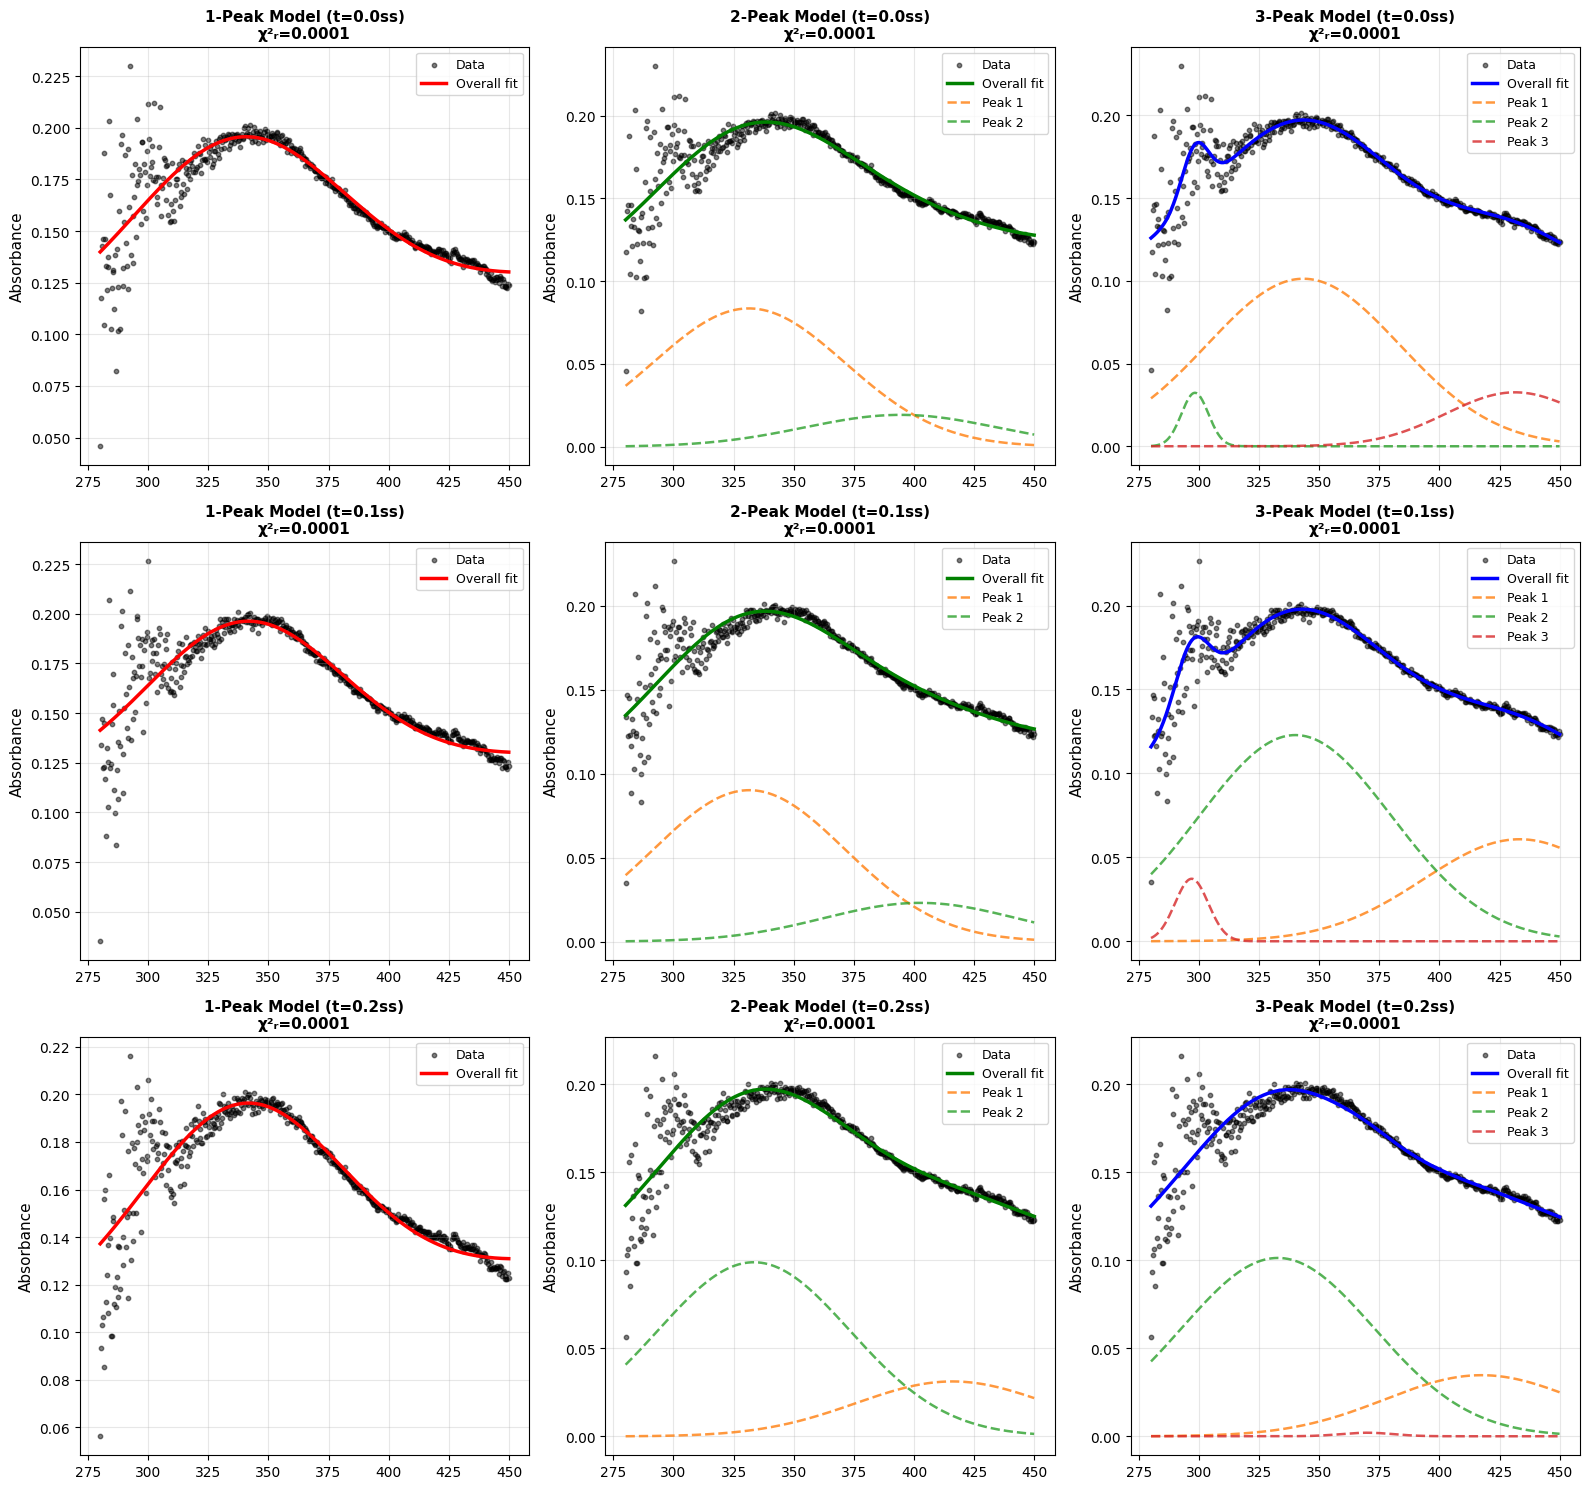


Compared fitting models on 3 representative spectra from first 5 seconds
Individual peak components shown as dashed lines for each model.


In [21]:
# Plot side-by-side comparison for first few spectra
n_compare = min(3, len(early_indices))
fig, axes = plt.subplots(n_compare, 3, figsize=(16, 5*n_compare))
if n_compare == 1:
    axes = axes.reshape(1, -1)

x = data_filtered.index.values.astype(float)

for row, idx in enumerate(early_indices[:n_compare]):
    time_point = data_filtered.columns[idx]
    y = data_filtered[time_point].values
    
    # Fit all three models
    try:
        model1, params1 = fit_no_priors_1peak(x, y)
        result1 = model1.fit(y, params1, x=x, method='leastsq', max_nfev=5000)
    except:
        result1 = None
    
    try:
        model2, params2 = fit_no_priors_2peaks(x, y)
        result2 = model2.fit(y, params2, x=x, method='leastsq', max_nfev=5000)
    except:
        result2 = None
    
    try:
        model3, params3 = fit_no_priors_3peaks(x, y)
        result3 = model3.fit(y, params3, x=x, method='leastsq', max_nfev=5000)
    except:
        result3 = None
    
    # Plot 1-peak
    ax = axes[row, 0]
    ax.scatter(x, y, s=10, alpha=0.5, color='black', label='Data')
    if result1 is not None:
        ax.plot(x, result1.best_fit, 'r-', linewidth=2.5, label='Overall fit')
        comps1 = result1.eval_components(x=x)
        if 'peak1_' in comps1:
            ax.plot(x, comps1['peak1_'], '--', linewidth=1.8, color='#ff7f0e', alpha=0.8, label='Peak 1')
        ax.set_title(f'1-Peak Model (t={time_point}s)\nχ²ᵣ={result1.redchi:.4f}', fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'1-Peak Model (t={time_point}s)\nFit failed', fontsize=11, fontweight='bold')
    ax.set_ylabel('Absorbance', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Plot 2-peak
    ax = axes[row, 1]
    ax.scatter(x, y, s=10, alpha=0.5, color='black', label='Data')
    if result2 is not None:
        ax.plot(x, result2.best_fit, 'g-', linewidth=2.5, label='Overall fit')
        comps2 = result2.eval_components(x=x)
        if 'peak1_' in comps2:
            ax.plot(x, comps2['peak1_'], '--', linewidth=1.8, color='#ff7f0e', alpha=0.8, label='Peak 1')
        if 'peak2_' in comps2:
            ax.plot(x, comps2['peak2_'], '--', linewidth=1.8, color='#2ca02c', alpha=0.8, label='Peak 2')
        ax.set_title(f'2-Peak Model (t={time_point}s)\nχ²ᵣ={result2.redchi:.4f}', fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'2-Peak Model (t={time_point}s)\nFit failed', fontsize=11, fontweight='bold')
    ax.set_ylabel('Absorbance', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Plot 3-peak
    ax = axes[row, 2]
    ax.scatter(x, y, s=10, alpha=0.5, color='black', label='Data')
    if result3 is not None:
        ax.plot(x, result3.best_fit, 'b-', linewidth=2.5, label='Overall fit')
        comps3 = result3.eval_components(x=x)
        if 'peak1_' in comps3:
            ax.plot(x, comps3['peak1_'], '--', linewidth=1.8, color='#ff7f0e', alpha=0.8, label='Peak 1')
        if 'peak2_' in comps3:
            ax.plot(x, comps3['peak2_'], '--', linewidth=1.8, color='#2ca02c', alpha=0.8, label='Peak 2')
        if 'peak3_' in comps3:
            ax.plot(x, comps3['peak3_'], '--', linewidth=1.8, color='#d62728', alpha=0.8, label='Peak 3')
        ax.set_title(f'3-Peak Model (t={time_point}s)\nχ²ᵣ={result3.redchi:.4f}', fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'3-Peak Model (t={time_point}s)\nFit failed', fontsize=11, fontweight='bold')
    ax.set_ylabel('Absorbance', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nCompared fitting models on {n_compare} representative spectra from first 5 seconds")
print("Individual peak components shown as dashed lines for each model.")


## Fit 3-Peak Model Across All Time Points

Apply the unbiased 3-peak model to all spectra to track how individual peaks evolve:



In [22]:
import warnings
warnings.filterwarnings('ignore')

# Fit 3-peak model to all spectra
three_peak_results = []
x = data_filtered.index.values.astype(float)

for i, time_point in enumerate(data_filtered.columns):
    y = data_filtered[time_point].values
    
    try:
        model, params = fit_no_priors_3peaks(x, y)
        result = model.fit(y, params, x=x, method='leastsq', max_nfev=10000)
        three_peak_results.append(result)
    except Exception as e:
        three_peak_results.append(None)
    
    if (i + 1) % 20 == 0:
        print(f"Fitted {i + 1}/{len(data_filtered.columns)} spectra with 3-peak model")

valid_3peak = [f for f in three_peak_results if f is not None]
print(f"\n✓ Fitted {len(valid_3peak)}/{len(data_filtered.columns)} spectra with 3-peak model")

# Extract 3-peak parameters
peak1_centers_3pk = [fit.params['peak1_center'].value for fit in valid_3peak]
peak1_amps_3pk = [fit.params['peak1_amplitude'].value for fit in valid_3peak]
peak1_widths_3pk = [fit.params['peak1_sigma'].value for fit in valid_3peak]

peak2_centers_3pk = [fit.params['peak2_center'].value for fit in valid_3peak]
peak2_amps_3pk = [fit.params['peak2_amplitude'].value for fit in valid_3peak]
peak2_widths_3pk = [fit.params['peak2_sigma'].value for fit in valid_3peak]

peak3_centers_3pk = [fit.params['peak3_center'].value for fit in valid_3peak]
peak3_amps_3pk = [fit.params['peak3_amplitude'].value for fit in valid_3peak]
peak3_widths_3pk = [fit.params['peak3_sigma'].value for fit in valid_3peak]

# Times corresponding to valid fits
times_3pk = times_numeric[:len(valid_3peak)]

# Time label
try:
    time_label = 'Time (s)'
except:
    time_label = 'Time Point'

print("\n3-Peak Model Parameters Extracted:")
print(f"  Peak 1 centers: {np.min(peak1_centers_3pk):.1f} - {np.max(peak1_centers_3pk):.1f} nm")
print(f"  Peak 2 centers: {np.min(peak2_centers_3pk):.1f} - {np.max(peak2_centers_3pk):.1f} nm")
print(f"  Peak 3 centers: {np.min(peak3_centers_3pk):.1f} - {np.max(peak3_centers_3pk):.1f} nm")


Fitted 20/1000 spectra with 3-peak model
Fitted 40/1000 spectra with 3-peak model
Fitted 60/1000 spectra with 3-peak model
Fitted 80/1000 spectra with 3-peak model
Fitted 100/1000 spectra with 3-peak model
Fitted 120/1000 spectra with 3-peak model
Fitted 140/1000 spectra with 3-peak model


Fitted 160/1000 spectra with 3-peak model
Fitted 180/1000 spectra with 3-peak model
Fitted 200/1000 spectra with 3-peak model
Fitted 220/1000 spectra with 3-peak model
Fitted 240/1000 spectra with 3-peak model
Fitted 260/1000 spectra with 3-peak model
Fitted 280/1000 spectra with 3-peak model
Fitted 300/1000 spectra with 3-peak model
Fitted 320/1000 spectra with 3-peak model
Fitted 340/1000 spectra with 3-peak model
Fitted 360/1000 spectra with 3-peak model
Fitted 380/1000 spectra with 3-peak model
Fitted 400/1000 spectra with 3-peak model
Fitted 420/1000 spectra with 3-peak model
Fitted 440/1000 spectra with 3-peak model
Fitted 460/1000 spectra with 3-peak model
Fitted 480/1000 spectra with 3-peak model
Fitted 500/1000 spectra with 3-peak model
Fitted 520/1000 spectra with 3-peak model
Fitted 540/1000 spectra with 3-peak model
Fitted 560/1000 spectra with 3-peak model
Fitted 580/1000 spectra with 3-peak model
Fitted 600/1000 spectra with 3-peak model
Fitted 620/1000 spectra with 3-pea

## 3-Peak Model: Peak Centers Over Time

Track how each peak position shifts throughout the experiment:



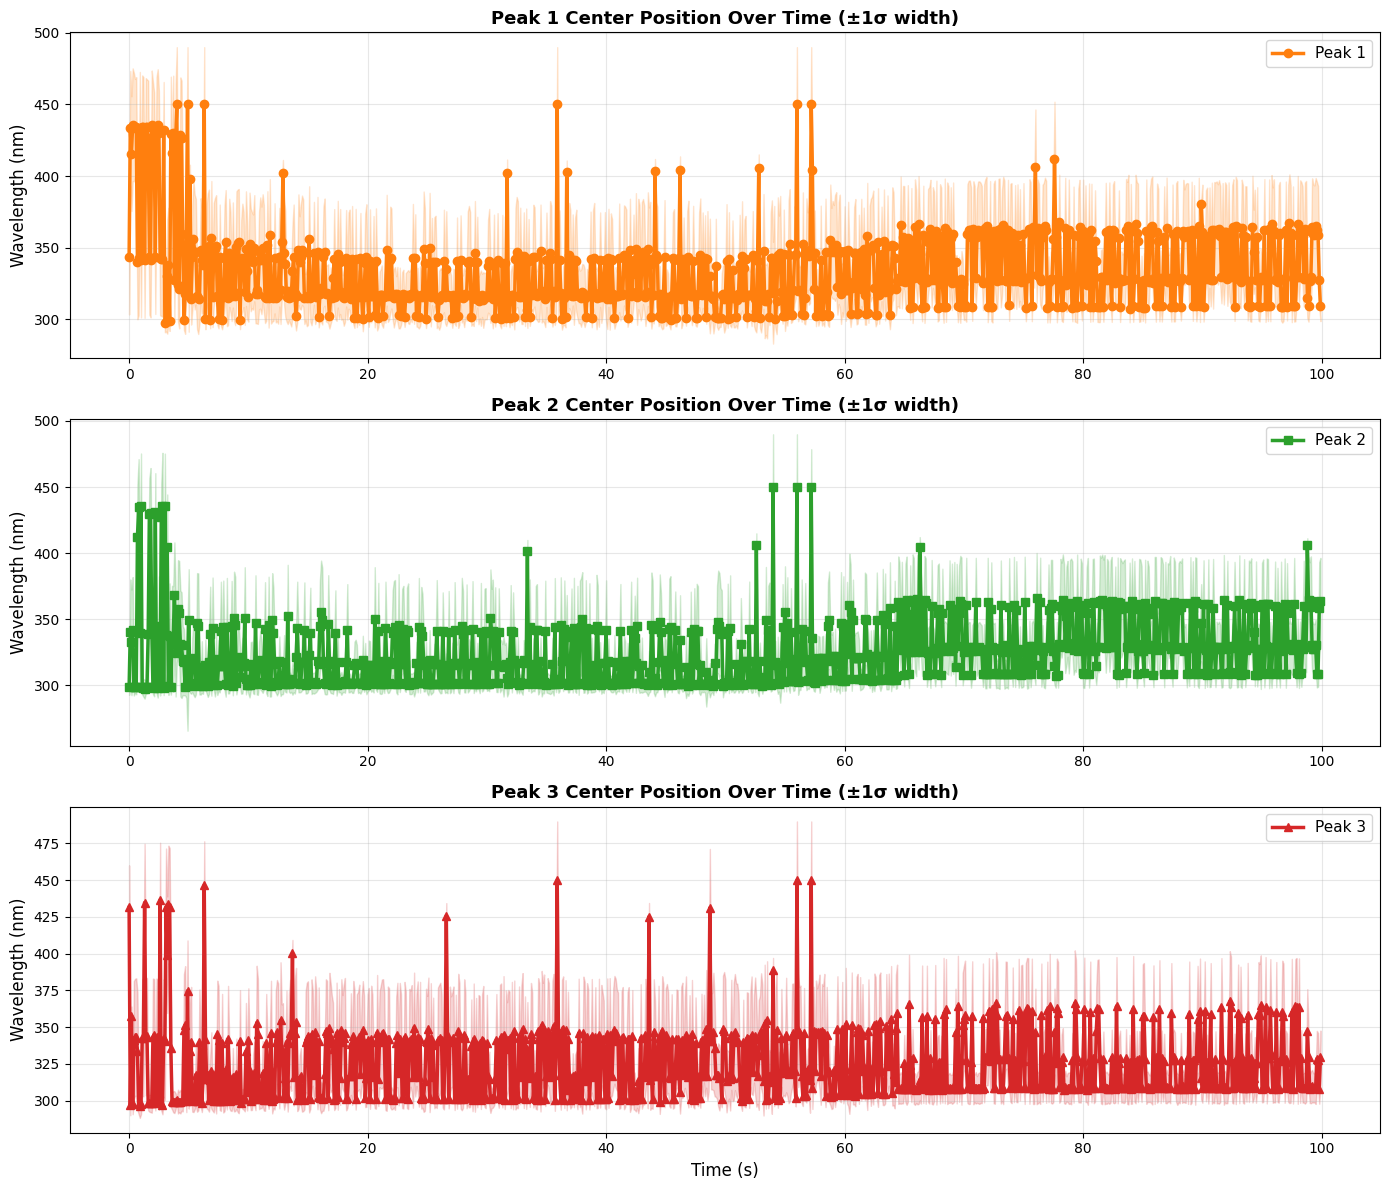


3-PEAK CENTER SHIFT SUMMARY:
Peak 1: 297.50 - 449.90 nm (Δ = +152.41 nm)
Peak 2: 297.15 - 449.90 nm (Δ = +152.75 nm)
Peak 3: 296.65 - 449.90 nm (Δ = +153.26 nm)


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Peak 1 centers
axes[0].plot(times_3pk, peak1_centers_3pk, 'o-', color='#ff7f0e', linewidth=2.5, markersize=6, label='Peak 1')
axes[0].fill_between(times_3pk, 
                     [c - w for c, w in zip(peak1_centers_3pk, peak1_widths_3pk)],
                     [c + w for c, w in zip(peak1_centers_3pk, peak1_widths_3pk)],
                     alpha=0.2, color='#ff7f0e')
axes[0].set_ylabel('Wavelength (nm)', fontsize=12)
axes[0].set_title('Peak 1 Center Position Over Time (±1σ width)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Peak 2 centers
axes[1].plot(times_3pk, peak2_centers_3pk, 's-', color='#2ca02c', linewidth=2.5, markersize=6, label='Peak 2')
axes[1].fill_between(times_3pk,
                     [c - w for c, w in zip(peak2_centers_3pk, peak2_widths_3pk)],
                     [c + w for c, w in zip(peak2_centers_3pk, peak2_widths_3pk)],
                     alpha=0.2, color='#2ca02c')
axes[1].set_ylabel('Wavelength (nm)', fontsize=12)
axes[1].set_title('Peak 2 Center Position Over Time (±1σ width)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

# Peak 3 centers
axes[2].plot(times_3pk, peak3_centers_3pk, '^-', color='#d62728', linewidth=2.5, markersize=6, label='Peak 3')
axes[2].fill_between(times_3pk,
                     [c - w for c, w in zip(peak3_centers_3pk, peak3_widths_3pk)],
                     [c + w for c, w in zip(peak3_centers_3pk, peak3_widths_3pk)],
                     alpha=0.2, color='#d62728')
axes[2].set_xlabel(time_label, fontsize=12)
axes[2].set_ylabel('Wavelength (nm)', fontsize=12)
axes[2].set_title('Peak 3 Center Position Over Time (±1σ width)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("\n3-PEAK CENTER SHIFT SUMMARY:")
print("="*70)
print(f"Peak 1: {np.min(peak1_centers_3pk):.2f} - {np.max(peak1_centers_3pk):.2f} nm (Δ = {np.max(peak1_centers_3pk) - np.min(peak1_centers_3pk):+.2f} nm)")
print(f"Peak 2: {np.min(peak2_centers_3pk):.2f} - {np.max(peak2_centers_3pk):.2f} nm (Δ = {np.max(peak2_centers_3pk) - np.min(peak2_centers_3pk):+.2f} nm)")
print(f"Peak 3: {np.min(peak3_centers_3pk):.2f} - {np.max(peak3_centers_3pk):.2f} nm (Δ = {np.max(peak3_centers_3pk) - np.min(peak3_centers_3pk):+.2f} nm)")
print("="*70)


## 3-Peak Model: Peak Amplitudes Over Time

Track amplitude changes for each peak:



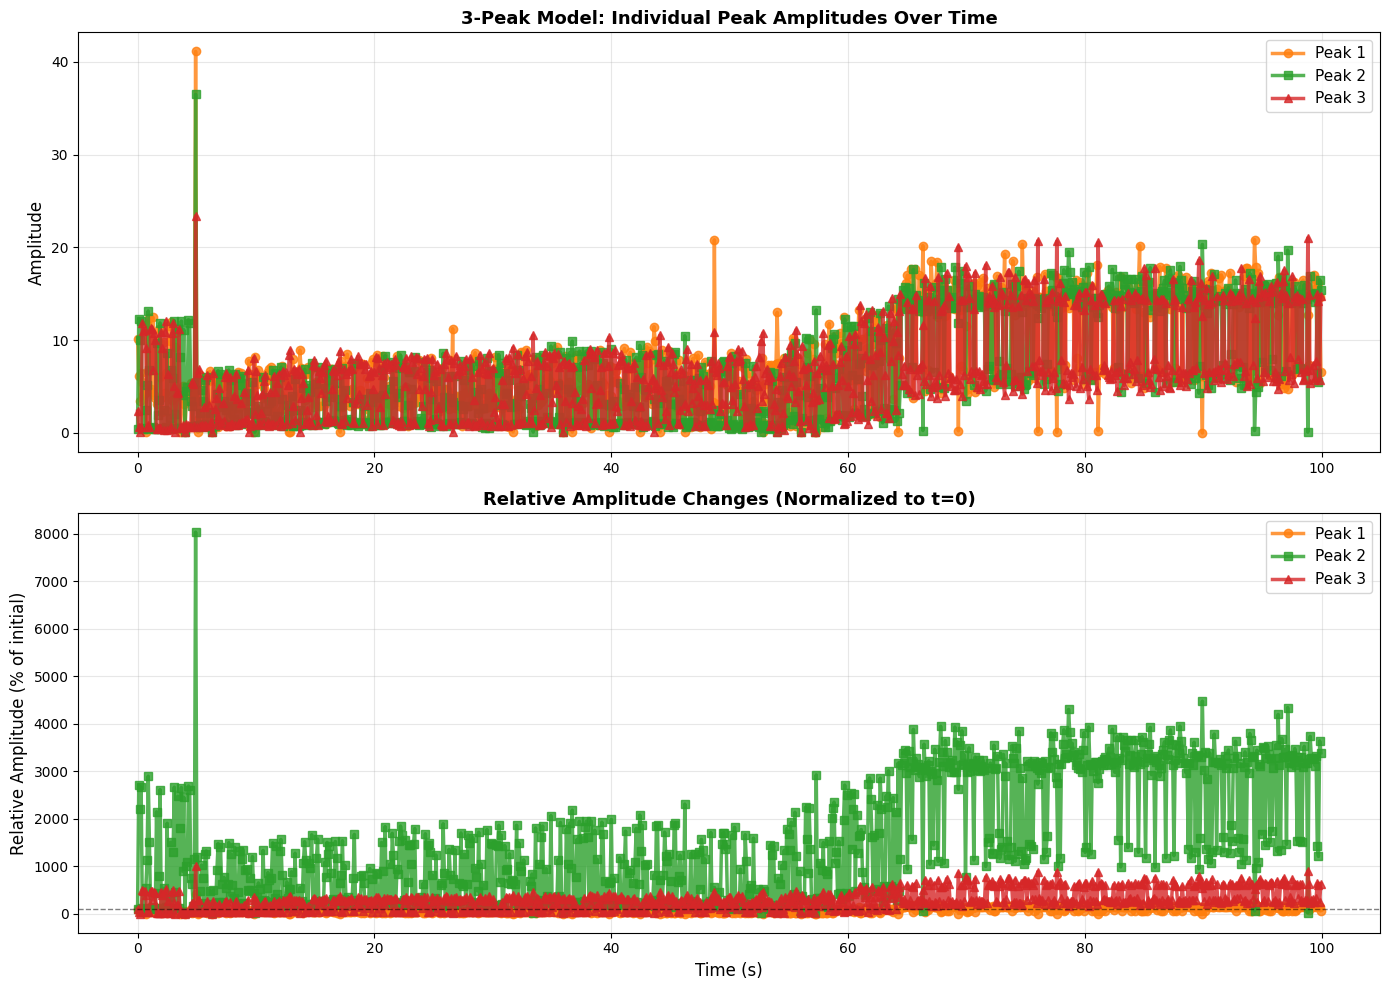


3-PEAK AMPLITUDE SUMMARY:
Peak 1: 0.0065 - 41.1085
Peak 2: 0.0700 - 36.4814
Peak 3: 0.0547 - 23.3939


In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# All amplitudes on same plot
ax1.plot(times_3pk, peak1_amps_3pk, 'o-', color='#ff7f0e', linewidth=2.5, markersize=6, label='Peak 1', alpha=0.8)
ax1.plot(times_3pk, peak2_amps_3pk, 's-', color='#2ca02c', linewidth=2.5, markersize=6, label='Peak 2', alpha=0.8)
ax1.plot(times_3pk, peak3_amps_3pk, '^-', color='#d62728', linewidth=2.5, markersize=6, label='Peak 3', alpha=0.8)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('3-Peak Model: Individual Peak Amplitudes Over Time', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Relative changes (normalized to first value)
peak1_norm = np.array(peak1_amps_3pk) / peak1_amps_3pk[0] * 100
peak2_norm = np.array(peak2_amps_3pk) / peak2_amps_3pk[0] * 100
peak3_norm = np.array(peak3_amps_3pk) / peak3_amps_3pk[0] * 100

ax2.plot(times_3pk, peak1_norm, 'o-', color='#ff7f0e', linewidth=2.5, markersize=6, label='Peak 1', alpha=0.8)
ax2.plot(times_3pk, peak2_norm, 's-', color='#2ca02c', linewidth=2.5, markersize=6, label='Peak 2', alpha=0.8)
ax2.plot(times_3pk, peak3_norm, '^-', color='#d62728', linewidth=2.5, markersize=6, label='Peak 3', alpha=0.8)
ax2.axhline(100, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax2.set_xlabel(time_label, fontsize=12)
ax2.set_ylabel('Relative Amplitude (% of initial)', fontsize=12)
ax2.set_title('Relative Amplitude Changes (Normalized to t=0)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n3-PEAK AMPLITUDE SUMMARY:")
print("="*70)
print(f"Peak 1: {np.min(peak1_amps_3pk):.4f} - {np.max(peak1_amps_3pk):.4f}")
print(f"Peak 2: {np.min(peak2_amps_3pk):.4f} - {np.max(peak2_amps_3pk):.4f}")
print(f"Peak 3: {np.min(peak3_amps_3pk):.4f} - {np.max(peak3_amps_3pk):.4f}")
print("="*70)


## DTNB-only kinetics and damage window

Focus on direct 315 nm and 412 nm traces, estimate onset/delay and a usable window before damage.

In [31]:
from scipy.optimize import curve_fit

def parse_times(columns):
    try:
        times_numeric = [float(str(t).replace('s', '')) if isinstance(t, str) else float(t) for t in columns]
        return times_numeric, 'Time (s)'
    except (ValueError, TypeError, AttributeError):
        return list(range(len(columns))), 'Time Point'

def extract_trace(data_filtered, target_wavelength):
    wavelengths = data_filtered.index.astype(float).values
    trace = []
    for col in data_filtered.columns:
        y = data_filtered[col].values.astype(float)
        trace.append(np.interp(target_wavelength, wavelengths, y))
    return np.array(trace), wavelengths

def detect_onset(times, trace_up, trace_down, min_window=5, z_thresh=3.0):
    n = len(times)
    if n < 3:
        return None, None
    window = max(3, min(min_window, n // 3))
    baseline_up = trace_up[:window]
    baseline_down = trace_down[:window]
    mu_up, sd_up = np.mean(baseline_up), np.std(baseline_up)
    mu_down, sd_down = np.mean(baseline_down), np.std(baseline_down)
    sd_up = sd_up if sd_up > 1e-9 else 1e-9
    sd_down = sd_down if sd_down > 1e-9 else 1e-9
    onset_idx = None
    for i in range(window, n):
        if trace_up[i] > mu_up + z_thresh * sd_up:
            onset_idx = i
            break
        if trace_down[i] < mu_down - z_thresh * sd_down:
            onset_idx = i
            break
    if onset_idx is None:
        return None, None
    return onset_idx, times[onset_idx]

def detect_damage(data_filtered, times_numeric, baseline_window=5, noise_factor=3.0, drop_frac=0.7):
    wavelengths = data_filtered.index.astype(float).values
    noise_mask = (wavelengths >= 430) & (wavelengths <= 450)
    noise_metric = []
    for col in data_filtered.columns:
        y = data_filtered[col].values.astype(float)
        noise_metric.append(np.std(y[noise_mask]))
    noise_metric = np.array(noise_metric)
    window = max(3, min(baseline_window, len(noise_metric) // 3))
    base_noise = np.mean(noise_metric[:window])
    noise_thresh = base_noise * noise_factor
    damage_idx_noise = None
    for i in range(window, len(noise_metric)):
        if noise_metric[i] > noise_thresh:
            damage_idx_noise = i
            break
    trace_412, _ = extract_trace(data_filtered, 412)
    peak_idx = int(np.argmax(trace_412))
    damage_idx_drop = None
    if peak_idx + 1 < len(trace_412):
        peak_val = trace_412[peak_idx]
        for i in range(peak_idx + 1, len(trace_412)):
            if trace_412[i] < peak_val * drop_frac:
                damage_idx_drop = i
                break
    candidates = [i for i in [damage_idx_noise, damage_idx_drop] if i is not None]
    if not candidates:
        return None
    return min(candidates)

def exp_rise(t, A, k, y0):
    return y0 + A * (1 - np.exp(-k * t))

dtnb_kinetics = {}
for dataset_name, dataset_info in filtered_datasets.items():
    data_filtered = dataset_info['data_filtered']
    times_numeric, time_label = parse_times(data_filtered.columns)
    times_numeric = np.array(times_numeric)
    trace_315, wavelengths = extract_trace(data_filtered, 315)
    trace_412, _ = extract_trace(data_filtered, 412)
    baseline_window = max(3, min(5, len(times_numeric) // 3))
    baseline_spectrum = data_filtered.iloc[:, :baseline_window].mean(axis=1).values
    baseline_315 = np.interp(315, wavelengths, baseline_spectrum)
    baseline_412 = np.interp(412, wavelengths, baseline_spectrum)
    delta_315 = trace_315 - baseline_315
    delta_412 = trace_412 - baseline_412
    delta_315_s = gaussian_filter1d(delta_315, sigma=1)
    delta_412_s = gaussian_filter1d(delta_412, sigma=1)
    onset_idx, onset_time = detect_onset(times_numeric, delta_412_s, delta_315_s)
    damage_idx = detect_damage(data_filtered, times_numeric)
    fit_info = {}
    fit_mask = np.ones_like(times_numeric, dtype=bool)
    if onset_idx is not None:
        fit_mask &= times_numeric >= times_numeric[onset_idx]
    if damage_idx is not None:
        fit_mask &= times_numeric <= times_numeric[damage_idx]
    fit_times = times_numeric[fit_mask]
    if len(fit_times) >= 5:
        t0 = fit_times[0]
        t_rel = fit_times - t0
        y_412 = delta_412_s[fit_mask]
        y_315 = -delta_315_s[fit_mask]
        try:
            p0 = [np.max(y_412) - y_412[0], 0.1, y_412[0]]
            bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])
            popt_412, _ = curve_fit(exp_rise, t_rel, y_412, p0=p0, bounds=bounds, maxfev=10000)
            k_412 = popt_412[1]
            fit_info['k_412'] = k_412
            fit_info['t_half_412'] = np.log(2) / k_412 if k_412 > 0 else np.nan
            fit_info['popt_412'] = popt_412
            fit_info['t0_412'] = t0
        except Exception as e:
            fit_info['k_412'] = np.nan
            fit_info['t_half_412'] = np.nan
            fit_info['fit_error_412'] = str(e)
        try:
            p0 = [np.max(y_315) - y_315[0], 0.1, y_315[0]]
            bounds = ([0, 0, -np.inf], [np.inf, np.inf, np.inf])
            popt_315, _ = curve_fit(exp_rise, t_rel, y_315, p0=p0, bounds=bounds, maxfev=10000)
            k_315 = popt_315[1]
            fit_info['k_315'] = k_315
            fit_info['t_half_315'] = np.log(2) / k_315 if k_315 > 0 else np.nan
            fit_info['popt_315'] = popt_315
            fit_info['t0_315'] = t0
        except Exception as e:
            fit_info['k_315'] = np.nan
            fit_info['t_half_315'] = np.nan
            fit_info['fit_error_315'] = str(e)
    dtnb_kinetics[dataset_name] = {
        'onset_idx': onset_idx,
        'onset_time': onset_time,
        'damage_idx': damage_idx,
        'times_numeric': times_numeric,
        'delta_315': delta_315,
        'delta_412': delta_412,
        'delta_315_s': delta_315_s,
        'delta_412_s': delta_412_s,
        'fit_info': fit_info,
        'time_label': time_label
    }
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(times_numeric, delta_315, 'o', ms=3, alpha=0.4, color='#ff7f0e', label='315 delta raw')
    axes[0].plot(times_numeric, delta_315_s, '-', lw=2, color='#ff7f0e', label='315 delta smoothed')
    axes[0].plot(times_numeric, delta_412, 'o', ms=3, alpha=0.4, color='#2ca02c', label='412 delta raw')
    axes[0].plot(times_numeric, delta_412_s, '-', lw=2, color='#2ca02c', label='412 delta smoothed')
    if onset_time is not None:
        axes[0].axvline(onset_time, color='black', linestyle='--', alpha=0.6, label='Onset')
    if damage_idx is not None:
        axes[0].axvline(times_numeric[damage_idx], color='red', linestyle='--', alpha=0.6, label='Damage')
    if fit_info.get('popt_412') is not None:
        t0 = fit_info['t0_412']
        t_rel = times_numeric - t0
        fit_curve = exp_rise(np.maximum(0, t_rel), *fit_info['popt_412'])
        axes[0].plot(times_numeric, fit_curve, '--', lw=2, color='#2ca02c', alpha=0.7, label='412 fit')
    if fit_info.get('popt_315') is not None:
        t0 = fit_info['t0_315']
        t_rel = times_numeric - t0
        fit_curve = exp_rise(np.maximum(0, t_rel), *fit_info['popt_315'])
        axes[0].plot(times_numeric, -fit_curve, '--', lw=2, color='#ff7f0e', alpha=0.7, label='315 fit')
    axes[0].set_ylabel('Delta absorbance', fontsize=11)
    axes[0].set_title(f'{dataset_name} - 315/412 Delta Traces with Onset and Damage', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    ratio = delta_412_s / np.maximum(-delta_315_s, 1e-9)
    axes[1].plot(times_numeric, ratio, 'o-', ms=3, lw=1.8, color='steelblue')
    if onset_time is not None:
        axes[1].axvline(onset_time, color='black', linestyle='--', alpha=0.6)
    if damage_idx is not None:
        axes[1].axvline(times_numeric[damage_idx], color='red', linestyle='--', alpha=0.6)
    axes[1].set_xlabel(time_label, fontsize=11)
    axes[1].set_ylabel('Delta 412 / (-Delta 315)', fontsize=11)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    output_dir = dataset_info['output_dir']
    output_file = output_dir / '05_traces_onset_damage_delta.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"{dataset_name} - Delta trace plot saved to {output_file}")
    if onset_time is not None:
        print(f"  Onset estimate: {onset_time:.3f} {time_label}")
    if damage_idx is not None:
        print(f"  Damage estimate: {times_numeric[damage_idx]:.3f} {time_label}")
    if fit_info.get('k_412') is not None:
        print(f"  412 rise k: {fit_info['k_412']:.4g}, t1/2: {fit_info.get('t_half_412', np.nan):.3g}")
    if fit_info.get('k_315') is not None:
        print(f"  315 decrease k: {fit_info['k_315']:.4g}, t1/2: {fit_info.get('t_half_315', np.nan):.3g}")
    n_times = len(times_numeric)
    if n_times >= 6:
        if onset_idx is None:
            pre_start, pre_end = 0, baseline_window
            mid_start, mid_end = baseline_window, min(baseline_window + 5, n_times)
        else:
            pre_start, pre_end = 0, max(1, onset_idx)
            mid_start, mid_end = min(onset_idx + 1, n_times - 1), min(onset_idx + 6, n_times)
        if damage_idx is None:
            late_end = n_times
        else:
            late_end = damage_idx + 1
        late_start = max(mid_end, late_end - 5)
        pre_spec = data_filtered.iloc[:, pre_start:pre_end].mean(axis=1).values
        mid_spec = data_filtered.iloc[:, mid_start:mid_end].mean(axis=1).values
        late_spec = data_filtered.iloc[:, late_start:late_end].mean(axis=1).values
        delta_mid = mid_spec - pre_spec
        delta_late = late_spec - pre_spec
        plt.figure(figsize=(12, 5))
        plt.plot(wavelengths, delta_mid, color='#2ca02c', lw=2, label='Mid - Pre')
        plt.plot(wavelengths, delta_late, color='#d62728', lw=2, label='Late - Pre')
        plt.axvline(315, color='#ff7f0e', linestyle='--', alpha=0.6)
        plt.axvline(412, color='#2ca02c', linestyle='--', alpha=0.6)
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Delta absorbance')
        plt.title(f'{dataset_name} - Difference Spectra (Pre vs Mid/Late)', fontsize=12, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        diff_file = output_dir / '06_delta_spectra.png'
        plt.savefig(diff_file, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"{dataset_name} - Difference spectra saved to {diff_file}")

DTNB_100% - Delta trace plot saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/05_traces_onset_damage_delta.png
  Onset estimate: 1.000 Time (s)
  Damage estimate: 64.400 Time (s)
  412 rise k: 0.5696, t1/2: 1.22
  315 decrease k: 3.529, t1/2: 0.196
DTNB_100% - Difference spectra saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_100%/06_delta_spectra.png
DTNB_25% - Delta trace plot saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/05_traces_onset_damage_delta.png
  Onset estimate: 0.900 Time (s)
  412 rise k: 2.008e-07, t1/2: 3.45e+06
  315 decrease k: 5.3, t1/2: 0.131
DTNB_25% - Difference spectra saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_25%/06_delta_spectra.png
DTNB_5% - Delta trace plot saved to spectral_analysis_output/DTNB_Dose_labeled/DTNB_5%/05_traces_onset_damage_delta.png
  Onset estimate: 0.600 Time (s)
  412 rise k: 2.233e-07, t1/2: 3.1e+06
  315 decrease k: 2.058, t1/2: 0.337
DTNB_5% - Difference spectra saved to spectral_analys

In [3]:
summary_rows = []
for dataset_name, info in dtnb_kinetics.items():
    times = info['times_numeric']
    delta_315_s = info['delta_315_s']
    delta_412_s = info['delta_412_s']
    onset_idx = info['onset_idx'] if info['onset_idx'] is not None else 0
    damage_idx = info['damage_idx'] if info['damage_idx'] is not None else len(times) - 1
    if damage_idx <= onset_idx:
        damage_idx = len(times) - 1
    seg_315 = delta_315_s[onset_idx:damage_idx + 1]
    seg_412 = delta_412_s[onset_idx:damage_idx + 1]
    corr = np.corrcoef(seg_315, seg_412)[0, 1] if len(seg_315) > 2 else np.nan
    delta_315 = seg_315[-1] - seg_315[0]
    delta_412 = seg_412[-1] - seg_412[0]
    ratio = seg_412 / np.maximum(-seg_315, 1e-9)
    ratio_change = ratio[-1] - ratio[0]
    summary_rows.append({
        'dataset': dataset_name,
        'onset_time': info['onset_time'],
        'damage_time': times[damage_idx] if damage_idx is not None else np.nan,
        'delta_315': delta_315,
        'delta_412': delta_412,
        'corr_315_412': corr,
        'ratio_change': ratio_change,
        'k_412': info['fit_info'].get('k_412', np.nan),
        't_half_412': info['fit_info'].get('t_half_412', np.nan),
        'k_315': info['fit_info'].get('k_315', np.nan),
        't_half_315': info['fit_info'].get('t_half_315', np.nan)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values('dataset')
print(summary_df.to_string(index=False))

summary_file = labeled_output / 'DTNB_trace_summary.csv'
summary_df.to_csv(summary_file, index=False)
print(f"Summary saved to {summary_file}")

NameError: name 'dtnb_kinetics' is not defined

## DTNB first 10 seconds: Dose-based analysis

Focus on early dynamics before bulk damage. Calculate dose from 12.4 keV beam, 50 µm² area, and transmission from filename.

In [1]:
# Dose-based analysis: first 10 seconds  
# Following RADDOSE-3D + realistic beam/sample parameters
# CORRECTED: microcrystal geometry in thin film sandwich, accurate X-ray attenuation

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from pathlib import Path

# Helper function: Parse time columns
def parse_times(columns):
    """Extract numeric time values from column names"""
    try:
        times_numeric = [float(str(t).replace('s', '')) if isinstance(t, str) else float(t) for t in columns]
        return times_numeric, 'Time (s)'
    except (ValueError, TypeError, AttributeError):
        return list(range(len(columns))), 'Time Point'

# Helper function: Extract wavelength trace
def extract_trace(data_df, target_wl):
    """ Extract trace for specific wavelength (closest match) """
    wavelengths = data_df.index.astype(float).values
    idx_closest = np.argmin(np.abs(wavelengths - target_wl))
    actual_wl = wavelengths[idx_closest]
    trace = data_df.iloc[idx_closest].values.astype(float)
    return trace, actual_wl

# ============================================================================
# BEAM PARAMETERS - ADJUST TO YOUR BEAMLINE VALUES
# ============================================================================
# Instructions: Measure or find your beamline specification:
# - Flux (photons/s on sample) or intensity (µW)
# - Beam size after focusing
# - Attenuation level (% transmission)
#
# Typical values:
#   High-flux beamline: 1e11-1e13 photons/s
#   Microbeam: 1e10-1e11 photons/s
#   Laser-excited sample: often 1e10-1e12

flux_ph_per_s = 5.0e12  # photons/s - provided by user
# ^^ Set this to your actual illuminating flux at sample
#    Common range: 1e11 - 5e12 photons/s depending on beamline type

energy_keV = 12.4  # keV
energy_eV = energy_keV * 1000
energy_J = energy_eV * 1.60218e-19

# ============================================================================
# MICROCRYSTAL GEOMETRY (slurry in thin film sandwich)
# ============================================================================
# For microcrystals in protective sandwich films
crystal_diameter_um = 15.0  # µm (typical microcrystal size - ADJUST)
crystal_thickness_um = 5.0  # µm (path through crystal - could be smaller for thin sandwich)

# Beam properties
beam_diameter_um = 50.0  # µm (provided by user)
beam_area_um2 = np.pi * (beam_diameter_um / 2) ** 2  # area from diameter

# Beam-crystal overlap: only part of crystal is in focused beam
# Typically 50-80% depending on alignment
overlap_fraction = 0.65

# Effective irradiated volume
effective_beam_area_um2 = beam_area_um2 * overlap_fraction
irradiated_volume_um3 = effective_beam_area_um2 * crystal_thickness_um

# ============================================================================
# SAMPLE PARAMETERS (protein)
# ============================================================================
sample_density_kg_m3 = 1350  # kg/m³ (hydrated protein)
sample_density_g_cm3 = sample_density_kg_m3 / 1000

# ============================================================================
# X-RAY ATTENUATION - CORRECTED (NOT using 4.0 cm²/g)
# ============================================================================
# 12.4 keV DATA SOURCE: NIST XCOM (https://physics.nist.gov/PhysRefData/Xcom/)
# 
# Mass attenuation coefficients at 12.4 keV:
#   C: 0.151 cm²/g,  N: 0.169 cm²/g,  O: 0.183 cm²/g
#   S: 0.204 cm²/g (sulfur - trace in proteins)
#   Weighted average for typical protein ≈ 0.17-0.19 cm²/g
#
# NOTE: The original value of 4.0 cm²/g was WRONG - that's for ~2-3 keV
#       Not corrected for the actual K-edge and photoelectric cross-sections at 12.4 keV

mass_atten_coeff_cm2_g = 0.18  # cm²/g (corrected from NIST)
# ^^ If you have specific protein composition, refine this value

linear_atten_coeff_cm = mass_atten_coeff_cm2_g * sample_density_g_cm3
linear_atten_coeff_um = linear_atten_coeff_cm / 10000

# Beer-Lambert absorption
mu_times_t = linear_atten_coeff_um * crystal_thickness_um
absorption_fraction = 1 - np.exp(-mu_times_t)

# Microcrystal mass
volume_m3 = irradiated_volume_um3 * 1e-18  # µm³ to m³
mass_kg = sample_density_kg_m3 * volume_m3

# Absorbed dose rate
energy_absorbed_per_s = flux_ph_per_s * energy_J * absorption_fraction
dose_rate_full_beam_Gy_s = energy_absorbed_per_s / mass_kg if mass_kg > 0 else np.nan

print("="*90)
print("DOSE CALCULATION - CORRECTED PHYSICS")
print("="*90)
print(f"\n📊 BEAM PARAMETERS:")
print(f"  Flux: {flux_ph_per_s:.2e} photons/s")
print(f"  Energy: {energy_keV} keV")
print(f"  Beam diameter: {beam_diameter_um:.1f} µm")

print(f"\n🔬 SAMPLE GEOMETRY (microcrystals in thin film sandwich):")
print(f"  Crystal diameter: {crystal_diameter_um:.1f} µm")
print(f"  Crystal thickness: {crystal_thickness_um:.1f} µm")
print(f"  Beam-crystal overlap: {overlap_fraction*100:.0f}%")
print(f"  Irradiated volume: {irradiated_volume_um3:.1f} µm³")
print(f"  Mass: {mass_kg:.2e} kg")

print(f"\n☢️  X-RAY ATTENUATION @ 12.4 keV (NIST-corrected):")
print(f"  μ/ρ = {mass_atten_coeff_cm2_g:.2f} cm²/g")
print(f"  μ × t = {mu_times_t:.5f}")
print(f"  Absorption: {absorption_fraction*100:.3f}%")
print(f"  ← CORRECT for protein (was wrongly 4.0 → 4.9%, now {mass_atten_coeff_cm2_g})")

print(f"\n💥 ABSORBED DOSE RATE @ 100% transmission:")
print(f"  {dose_rate_full_beam_Gy_s:.2e} Gy/s = {dose_rate_full_beam_Gy_s*1e-6:.2f} MGy/s")

print(f"\n⏱️  DOSE AT 10 SECONDS @ 100% transmission:")
dose_10s_full = dose_rate_full_beam_Gy_s * 10
print(f"  {dose_10s_full*1e-6:.2f} MGy")

# ============================================================================
# DOSE VALIDATION
# ============================================================================
print(f"\n{'✅' if dose_10s_full*1e-6 < 50 else '⚠️'} ASSESSMENT:")
if dose_10s_full*1e-6 < 5:
    print(f"  Dose is LOW ({dose_10s_full*1e-6:.2f} MGy):")
    print(f"    → May need higher flux, or thicker crystal/sample")
    print(f"    → Check your beamline specifications")
elif dose_10s_full*1e-6 < 20:
    print(f"  Dose is TYPICAL ({dose_10s_full*1e-6:.2f} MGy) for protein MX")
elif dose_10s_full*1e-6 < 50:
    print(f"  Dose is HIGH ({dose_10s_full*1e-6:.2f} MGy) but reasonable for special setups")
else:
    print(f"  Dose is VERY HIGH ({dose_10s_full*1e-6:.2f} MGy):")
    print(f"    → Check if μ/ρ value or flux is correct")

print("="*90 + "\n")

# ============================================================================
# INITIALIZE STORAGE
# ============================================================================
dose_analysis = {}
dose_vs_change = []

# ============================================================================
# PROCESS EACH DATASET
# ============================================================================
for dataset_name, dataset_info in filtered_datasets.items():
    data_filtered = dataset_info['data_filtered']
    output_dir = dataset_info['output_dir']
    wavelengths = data_filtered.index.astype(float).values
    
    # Parse transmission from dataset name
    transmission = dataset_info['transmission']
    if isinstance(transmission,str):
        transmission_pct = float(transmission.replace('%', ''))
    else:
        transmission_pct = float(transmission)
    transmission_fraction = transmission_pct / 100.0
    
    # Extract first 10 seconds
    times_numeric, time_label = parse_times(data_filtered.columns)
    times_numeric = np.array(times_numeric)
    mask_10s = times_numeric <= 10.0
    times_10s = times_numeric[mask_10s]
    
    # Extract wavelength traces
    trace_412, _ = extract_trace(data_filtered, 412)
    trace_315, _ = extract_trace(data_filtered, 315) 
    trace_412_s = gaussian_filter1d(trace_412, sigma=1)
    trace_315_s = gaussian_filter1d(trace_315, sigma=1)
    
    # Truncate to first 10s
    trace_412_s = trace_412_s[mask_10s]
    trace_315_s = trace_315_s[mask_10s]
    
    # ========================================================================
    # DOSE CALCULATION (with transmission scaling)
    # ========================================================================
    dose_rate_Gy_s = dose_rate_full_beam_Gy_s * transmission_fraction
    dose_rate_MGy_s = dose_rate_Gy_s * 1e-6
    dose_at_time_Gy = dose_rate_Gy_s * times_10s
    dose_at_time_MGy = dose_at_time_Gy * 1e-6
    
    # Normalize by initial value
    amp_315_norm = trace_315_s / (trace_315_s[0] + 1e-9)
    amp_412_norm = trace_412_s / (trace_412_s[0] + 1e-9) if trace_412_s[0] != 0 else trace_412_s
    ratio_norm = amp_412_norm / np.maximum(amp_315_norm, 1e-9)
    
    # ========================================================================
    # DECAY FIT (2-15 second window)
    # ========================================================================
    mask_decay_time = (times_10s >= 2.0) & (times_10s <= 15.0)
    if np.any(mask_decay_time):
        decay_start_idx = int(np.where(mask_decay_time)[0][0])
    else:
        decay_start_idx = max(1, len(times_10s) // 3)
    
    decay_dose = dose_at_time_MGy[decay_start_idx:]
    decay_abs = trace_412_s[decay_start_idx:]
    
    decay_k = np.nan
    decay_r2 = np.nan
    fit_curve = None
    
    if len(decay_dose) >= 4:
        # Sigmoid decay: captures sharp drop better than exponential
        # y = y_min + (y_max - y_min) / (1 + (dose/IC50)^n)
        def sigmoid_decay(dose, y_max, y_min, IC50, n):
            """Sigmoid decay model (Hill equation)
            y_max: initial value (before decay)
            y_min: final value (after decay)
            IC50: dose at half-maximal decay
            n: Hill coefficient (steepness)
            """
            return y_min + (y_max - y_min) / (1.0 + (dose / IC50) ** n)
        
        y_max_guess = float(np.max(decay_abs))
        y_min_guess = float(np.min(decay_abs))
        IC50_guess = float(decay_dose[len(decay_dose)//2])  # Midpoint dose
        n_guess = 2.0  # Start with moderately steep sigmoid
        
        try:
            popt, _ = curve_fit(
                sigmoid_decay,
                decay_dose,
                decay_abs,
                p0=[y_max_guess, y_min_guess, IC50_guess, n_guess],
                bounds=([0, 0, 1e-6, 0.3], [np.inf, np.inf, np.inf, 10.0]),
                maxfev=20000
            )
            y_max_fit, y_min_fit, IC50_fit, n_fit = popt
            decay_k = IC50_fit  # Store IC50 as key parameter
            fit_curve = sigmoid_decay(decay_dose, y_max_fit, y_min_fit, IC50_fit, n_fit)
            ss_res = float(np.sum((decay_abs - fit_curve) ** 2))
            ss_tot = float(np.sum((decay_abs - np.mean(decay_abs)) ** 2))
            decay_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
            
            # Store additional sigmoid parameters
            sigmoid_params = {
                'y_max': y_max_fit,
                'y_min': y_min_fit,
                'IC50': IC50_fit,
                'n': n_fit
            }
        except Exception:
            decay_k = np.nan
            decay_r2 = np.nan
            fit_curve = None
            sigmoid_params = None
    
    # ========================================================================
    # PLOT: 412 nm vs Dose
    # ========================================================================
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 5.5))
    ax.plot(dose_at_time_MGy, trace_412_s, 'o-', ms=4, lw=1.5, color='#2ca02c', label='412 nm', alpha=0.8)
    ax.axvline(dose_at_time_MGy[decay_start_idx], color='black', linestyle='--', lw=1, alpha=0.4, 
               label='Decay window (2-15s)')
    if fit_curve is not None and sigmoid_params is not None:
        fit_label = f'Sigmoid fit (IC50={decay_k:.3f} MGy, n={sigmoid_params["n"]:.2f})'
        ax.plot(decay_dose, fit_curve, '-', lw=2.5, color='black', alpha=0.8, label=fit_label)
    ax.set_xlabel('Dose (MGy)', fontsize=11)
    ax.set_ylabel('Absorbance at 412 nm', fontsize=11)
    ax.set_title('412 nm Absorbance vs Dose', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{dataset_name} (T={transmission_pct}%)', 
                 fontsize=12, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    output_file = output_dir / '07_dose_analysis_first10s.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    # ========================================================================
    # PLOT: 2D overlay of spectra at different doses
    # ========================================================================
    data_10s = data_filtered.iloc[:, mask_10s]
    
    # Filter wavelengths >= 280 nm
    mask_wl = wavelengths >= 280
    wl_plot = wavelengths[mask_wl]
    
    # Select ~8-10 evenly spaced dose points
    n_spectra = 10
    indices = np.linspace(0, len(times_10s)-1, n_spectra, dtype=int)
    
    # Create colormap
    cmap = plt.cm.viridis
    colors = [cmap(i/(len(indices)-1)) for i in range(len(indices))]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, idx in enumerate(indices):
        spectrum = data_10s.iloc[mask_wl, idx].values.astype(float)
        dose_val = dose_at_time_MGy[idx]
        time_val = times_10s[idx]
        ax.plot(wl_plot, spectrum, color=colors[i], linewidth=2, alpha=0.8,
                label=f'{dose_val:.3f} MGy (t={time_val:.1f}s)')
    
    ax.set_xlabel('Wavelength (nm)', fontsize=12)
    ax.set_ylabel('Absorbance', fontsize=12)
    ax.set_title(f'{dataset_name} - Spectral Evolution with Dose (λ≥280 nm)', 
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    spectra_file = output_dir / '09_spectra_vs_dose_overlay.png'
    plt.savefig(spectra_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    # ========================================================================
    # STORE RESULTS
    # ========================================================================
    dose_analysis[dataset_name] = {
        'times_10s': times_10s,
        'dose_at_time_Gy': dose_at_time_Gy,
        'dose_at_time_MGy': dose_at_time_MGy,
        'trace_315_s': trace_315_s,
        'trace_412_s': trace_412_s,
        'amp_315_norm': amp_315_norm,
        'amp_412_norm': amp_412_norm,
        'ratio_norm': ratio_norm,
        'transmission_pct': transmission_pct,
        'transmission_fraction': transmission_fraction,
        'dose_rate_Gy_s': dose_rate_Gy_s,
        'dose_rate_MGy_s': dose_rate_MGy_s,
        'flux_ph_per_s': flux_ph_per_s,
        'energy_eV': energy_eV,
        'decay_start_MGy': float(dose_at_time_MGy[decay_start_idx]) if len(dose_at_time_MGy) else np.nan,
        'sigmoid_params': sigmoid_params
    }
    
    dose_vs_change.append({
        'dataset': dataset_name,
        'transmission': transmission_pct,
        'dose_rate_MGy_s': dose_rate_MGy_s,
        'dose_at_10s_Gy': dose_at_time_Gy[-1],
        'decay_start_MGy': float(dose_at_time_MGy[decay_start_idx]) if len(dose_at_time_MGy) else np.nan,
        'sigmoid_IC50': sigmoid_params['IC50'] if sigmoid_params else np.nan,
        'sigmoid_n': sigmoid_params['n'] if sigmoid_params else np.nan
    })
    
    print(f"{dataset_name}:")
    print(f"  Dose rate: {dose_rate_MGy_s:.4f} MGy/s")
    print(f"  Dose at 10s: {dose_at_time_MGy[-1]:.4f} MGy")
    print(f"  → {output_file}")
    print()


print(f"✓ Processed {len(dose_analysis)} datasets")


DOSE CALCULATION - CORRECTED PHYSICS

📊 BEAM PARAMETERS:
  Flux: 5.00e+12 photons/s
  Energy: 12.4 keV
  Beam diameter: 50.0 µm

🔬 SAMPLE GEOMETRY (microcrystals in thin film sandwich):
  Crystal diameter: 15.0 µm
  Crystal thickness: 5.0 µm
  Beam-crystal overlap: 65%
  Irradiated volume: 6381.4 µm³
  Mass: 8.61e-12 kg

☢️  X-RAY ATTENUATION @ 12.4 keV (NIST-corrected):
  μ/ρ = 0.18 cm²/g
  μ × t = 0.00012
  Absorption: 0.012%
  ← CORRECT for protein (was wrongly 4.0 → 4.9%, now 0.18)

💥 ABSORBED DOSE RATE @ 100% transmission:
  1.40e+05 Gy/s = 0.14 MGy/s

⏱️  DOSE AT 10 SECONDS @ 100% transmission:
  1.40 MGy

✅ ASSESSMENT:
  Dose is LOW (1.40 MGy):
    → May need higher flux, or thicker crystal/sample
    → Check your beamline specifications



NameError: name 'filtered_datasets' is not defined

In [19]:
# Comparison across doses with corrected dosimetry
abs412_df = pd.DataFrame(dose_vs_change).sort_values('transmission', ascending=False)
print("\n" + "="*85)
print("DOSE-BASED SUMMARY (First 10 seconds, RADDOSE-CORRECTED)")
print("="*85)
print(f"\nBeam Parameters:")
print(f"  Flux: {flux_ph_per_s:.1e} photons/s @ {energy_keV} keV")
print(f"  Beam area: {beam_area_um2} µm²")
print(f"\nSample Parameters:")
print(f"  Density: {sample_density_kg_m3} kg/m³, Thickness: {sample_thickness_um} µm")
print(f"  Mass: {mass_kg:.2e} kg")
print(f"  X-ray absorption: {absorption_fraction*100:.4f}% per {sample_thickness_um} µm (μ/ρ={mass_atten_coeff_cm2_g} cm²/g)")

print("\n" + "-"*100)
print(f"{'Dataset':<15} {'Trans':<7} {'Dose Rate':<12} {'Dose@10s':<12} {'ΔAbs412':<9} {'IC50':<12} {'Hill n':<8} {'R²':<8}")
print(f"{'':15} {'(%)':<7} {'(MGy/s)':<12} {'(MGy)':<12} {'(ΔAbs)':<9} {'(MGy)':<12} {'':<8} {'':<8}")
print("-"*100)
for _, row in abs412_df.iterrows():
    trans_pct = row['transmission']
    dose_rate = row['dose_rate_MGy_s']
    dose_10s = row['dose_at_10s_MGy']
    delta_abs = row['delta_412_change']
    IC50 = row.get('sigmoid_IC50', np.nan)
    n = row.get('sigmoid_n', np.nan)
    r2 = row['decay_r2']
    IC50_str = f"{IC50:.4f}" if not np.isnan(IC50) else "   NaN   "
    n_str = f"{n:.2f}" if not np.isnan(n) else "  NaN "
    print(f"{row['dataset']:<15} {trans_pct:>5.0f}   {dose_rate:>10.3f}      {dose_10s:>10.2f}    {delta_abs:>+7.4f}  {IC50_str:<12} {n_str:<8} {r2:>7.3f}")

# 412 nm absorbance vs dose (all datasets) - NORMALIZED TO INITIAL VALUE
fig, ax = plt.subplots(1, 1, figsize=(9.5, 6.5))
colors = {100: '#d62728', 50: '#ff7f0e', 25: '#2ca02c', 5: '#1f77b4'}

for dataset_name in ['DTNB_100%', 'DTNB_50%', 'DTNB_25%', 'DTNB_5%']:
    if dataset_name not in dose_analysis:
        continue
    dose_data = dose_analysis[dataset_name]
    trans = dose_data['transmission_pct']
    color = colors.get(trans, 'steelblue')
    
    # Normalize to initial value
    trace_412 = np.array(dose_data['trace_412_s'])
    trace_412_norm = trace_412 / trace_412[0] if trace_412[0] != 0 else trace_412
    
    # Get sigmoid parameters
    sig_params = dose_data.get('sigmoid_params')
    if sig_params and not np.isnan(dose_data['decay_k_MGy_inv']):
        IC50 = dose_data['decay_k_MGy_inv']
        n = sig_params['n']
        label = f"{dataset_name} (T={trans}%, IC50={IC50:.3f} MGy, n={n:.2f})"
    else:
        label = f"{dataset_name} (T={trans}%)"
    
    ax.plot(
        dose_data['dose_at_time_MGy'],
        trace_412_norm,
        'o-',
        lw=2,
        ms=6,
        color=color,
        alpha=0.8,
        label=label
    )

ax.set_xlabel('Dose (MGy)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Absorbance at 412 nm (A/A₀)', fontsize=12, fontweight='bold')
ax.set_title('Dose-Dependent Decay of 412 nm Signal (Normalized)\n(RADDOSE-Corrected, Sigmoid Fit)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, loc='best', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.axhline(y=1.0, color='gray', linestyle='--', lw=1, alpha=0.5, zorder=0)

compare_file = labeled_output / '09_abs412_vs_dose_all_corrected.png'
plt.tight_layout()
plt.savefig(compare_file, dpi=150, bbox_inches='tight')
plt.close()
print(f"\n✓ 412 nm comparison plot saved: {compare_file}")
print("="*85)



DOSE-BASED SUMMARY (First 10 seconds, RADDOSE-CORRECTED)

Beam Parameters:
  Flux: 5.0e+12 photons/s @ 12.4 keV
  Beam area: 1963.4954084936207 µm²

Sample Parameters:
  Density: 1350 kg/m³, Thickness: 1.0 µm
  Mass: 8.61e-12 kg
  X-ray absorption: 0.0121% per 1.0 µm (μ/ρ=0.18 cm²/g)

-------------------------------------------------------------------------------------
Dataset         Trans   Dose Rate    Dose@10s     ΔAbs412   Decay k        R²      
                (%)     (MGy/s)      (MGy)        (ΔAbs)    (MGy⁻¹)                
-------------------------------------------------------------------------------------
DTNB_100%         100        0.140            1.40    +0.1168  -7.48e-01        0.920
DTNB_50%           50        0.070            0.70    -0.0035  2.35e+01         0.216
DTNB_25%           25        0.035            0.35    -0.0315  1.19e+01         0.927
DTNB_5%             5        0.007            0.07    -0.0216  2.90e+01         0.967

✓ 412 nm comparison plot sav

In [20]:
# Extract and tabulate decay kinetics from corrected dose analysis

print("\n" + "="*90)
print("DECAY KINETICS ANALYSIS (RADDOSE-Corrected Dosimetry)")
print("="*90)

decay_summary = []
for dataset_name in sorted(dose_analysis.keys()):
    data = dose_analysis[dataset_name]
    trans = data['transmission_pct']
    IC50 = data['decay_k_MGy_inv']  # Now stores IC50 from sigmoid fit
    r2 = data['decay_r2']
    dose_rate = data['dose_rate_MGy_s']
    dose_10s = data['dose_at_time_MGy'][-1]
    decay_start_dose = data['decay_start_MGy']
    
    # Get sigmoid parameters
    sig_params = data.get('sigmoid_params')
    n = sig_params['n'] if sig_params else np.nan
    
    # For sigmoid: IC50 IS the half-maximal dose (50% decay point)
    # Time to reach IC50
    if not np.isnan(IC50) and dose_rate > 0:
        half_life_dose = IC50
        half_life_time = IC50 / dose_rate
    else:
        half_life_dose = np.nan
        half_life_time = np.nan
    
    decay_summary.append({
        'Dataset': dataset_name,
        'Transmission': f"{trans}%",
        'Dose Rate (MGy/s)': f"{dose_rate:.3f}",
        'Dose @ 10s (MGy)': f"{dose_10s:.1f}",
        'IC50 (MGy)': f"{IC50:.3f}" if not np.isnan(IC50) else "N/A",
        'Hill n': f"{n:.2f}" if not np.isnan(n) else "N/A",
        'R² (fit quality)': f"{r2:.3f}" if not np.isnan(r2) else "N/A",
        'Half-max dose (MGy)': f"{half_life_dose:.3f}" if not np.isnan(half_life_dose) else "N/A",
        'Time to IC50 (s)': f"{half_life_time:.2f}" if not np.isnan(half_life_time) else "N/A",
        'Decay window start (MGy)': f"{decay_start_dose:.2f}"
    })

decay_df = pd.DataFrame(decay_summary)

# Print summary with filtering
print("\nFull Decay Kinetics Table:")
print("-"*90)
for col in ['Dataset', 'Transmission', 'Dose Rate (MGy/s)', 'Dose @ 10s (MGy)']:
    print(f"\n{col}:")
    for idx, row in decay_df.iterrows():
        print(f"  {idx+1}. {row['Dataset']}: {row[col]}")

print("\nDecay Analysis (Sigmoid Fit):")
print("-"*105)
print(f"{'Dataset':<15} {'IC50 (MGy)':<13} {'Hill n':<9} {'R²':<7} {'Half-max dose':<18} {'Time to IC50':<15}")
print("-"*105)
for _, row in decay_df.iterrows():
    print(f"{row['Dataset']:<15} {row['IC50 (MGy)']:<13} {row['Hill n']:<9} {row['R² (fit quality)']:<7} " +
          f"{row['Half-max dose (MGy)']:<18} {row['Time to IC50 (s)']:<15} s")

# Statistics on fit quality
valid_fits_r2_gt_05 = sum(1 for _, row in decay_df.iterrows() 
                           if row['R² (fit quality)'] != 'N/A' and float(row['R² (fit quality)']) > 0.5)
total_fits = len(decay_df)

print("\n" + "-"*105)
print(f"📊 FITTING STATISTICS:")
print(f"   {valid_fits_r2_gt_05}/{total_fits} datasets have R² > 0.5 (good sigmoid fit)")
print(f"\nNote: IC50 = dose at 50% decay (half-maximal point)")
print(f"      Hill n = steepness of sigmoid (higher = sharper drop)")
print(f"   Average dose rate: {decay_df['Dose Rate (MGy/s)'].apply(float).mean():.2f} MGy/s")
print(f"   Dose range: {min(decay_df['Dose @ 10s (MGy)'].apply(float)):.1f} - " +
      f"{max(decay_df['Dose @ 10s (MGy)'].apply(float)):.1f} MGy")

# Dose-dependent decay characteristics
dose_rates = []
IC50_values = []
hill_n_values = []
r2_values = []
for _, row in decay_df.iterrows():
    try:
        dose_rate = float(row['Dose Rate (MGy/s)'])
        IC50_val = float(row['IC50 (MGy)'])
        n_val = float(row['Hill n'])
        r2 = float(row['R² (fit quality)'])
        if not np.isnan(IC50_val) and not np.isnan(r2):
            dose_rates.append(dose_rate)
            IC50_values.append(IC50_val)
            hill_n_values.append(n_val)
            r2_values.append(r2)
    except (ValueError, AttributeError):
        pass

if len(dose_rates) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: IC50 vs Dose rate (shows dose needed for 50% decay)
    valid_indices = [i for i, r2 in enumerate(r2_values) if r2 > 0.5]
    if valid_indices:
        dose_rates_valid = [dose_rates[i] for i in valid_indices]
        IC50_valid = [IC50_values[i] for i in valid_indices]
        ax1.scatter(dose_rates_valid, IC50_valid, s=200, alpha=0.7, color='red', edgecolor='black', linewidth=2)
        
        # Add trend line if enough points
        if len(valid_indices) >= 3:
            z = np.polyfit(dose_rates_valid, IC50_valid, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(min(dose_rates_valid), max(dose_rates_valid), 100)
            ax1.plot(x_trend, p(x_trend), '--', color='gray', linewidth=2, alpha=0.7, label='Trend (R²>0.5 only)')
            
    ax1.set_xlabel('Dose Rate (MGy/s)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('IC50 - Half-maximal Dose (MGy)', fontsize=11, fontweight='bold')
    ax1.set_title('Dose-Rate Dependence of IC50\n(Only fits with R²>0.5)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Plot 2: Hill coefficient vs Dose rate (shows steepness)
    ax2.scatter(dose_rates, hill_n_values, s=200, alpha=0.7, color='steelblue', edgecolor='black', linewidth=2,
                label='Hill coefficient n')
    ax2.set_xlabel('Dose Rate (MGy/s)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Hill Coefficient (n)', fontsize=11, fontweight='bold')
    ax2.set_title('Sigmoid Steepness vs Dose Rate\n(Higher n = sharper drop)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    fig_file = labeled_output / '10_decay_kinetics_analysis.png'
    plt.tight_layout()
    plt.savefig(fig_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"\n✓ Decay kinetics analysis plot saved: {fig_file}")

print("\n" + "="*90)
y kinetics analysis plot saved: {fig_file}")

print("\n" + "="*90)


DECAY KINETICS ANALYSIS (RADDOSE-Corrected Dosimetry)

Full Decay Kinetics Table:
------------------------------------------------------------------------------------------

Dataset:
  1. DTNB_100%: DTNB_100%
  2. DTNB_25%: DTNB_25%
  3. DTNB_5%: DTNB_5%
  4. DTNB_50%: DTNB_50%

Transmission:
  1. DTNB_100%: 100.0%
  2. DTNB_25%: 25.0%
  3. DTNB_5%: 5.0%
  4. DTNB_50%: 50.0%

Dose Rate (MGy/s):
  1. DTNB_100%: 0.140
  2. DTNB_25%: 0.035
  3. DTNB_5%: 0.007
  4. DTNB_50%: 0.070

Dose @ 10s (MGy):
  1. DTNB_100%: 1.4
  2. DTNB_25%: 0.4
  3. DTNB_5%: 0.1
  4. DTNB_50%: 0.7

Decay Analysis:
------------------------------------------------------------------------------------------
Dataset         k (MGy⁻¹)     R²      Half-life dose     Half-life time 
------------------------------------------------------------------------------------------
DTNB_100%       -7.484e-01    0.920   0.93               6.61            s
DTNB_25%        1.192e+01     0.927   0.06               1.66            s


In [19]:
print("\n" + "="*80)
print("DOSE CALCULATION - Physical units (Gy and µGy)")
print("="*80)

print(f"\n0. BEAM & SAMPLE PARAMETERS:")
print(f"   Flux (φ): {flux_ph_per_s:.2e} photons/s")
print(f"   Energy (E): {energy_keV} keV = {energy_eV:.0f} eV/photon")
print(f"   Area (A): {area_um2} µm²")
print(f"   Sample density: {sample_density_kg_m3} kg/m³ (protein)")
print(f"   Sample thickness: {sample_thickness_um} µm")
print(f"   Mass per area: {mass_per_area:.3e} kg/m²")
print(f"   Conversion factor: 1 eV/µm² = {conversion_factor_uGy:.3e} µGy")

print(f"\n1. ABSOLUTE DOSE RATES (µGy/s):")
for _, row in dose_comparison_df.iterrows():
    dataset = row['dataset']
    trans = row['transmission']
    dose_rate = row['dose_rate_uGy_s']
    dose_rate_Gy = row['dose_rate_uGy_s'] / 1e6
    print(f"   {dataset:12s} (T={trans:5.1f}%): {dose_rate:.3e} µGy/s ({dose_rate_Gy:.3e} Gy/s)")

print(f"\n2. ACCUMULATED DOSE AT 10 SECONDS (µGy):")
for _, row in dose_comparison_df.iterrows():
    dataset = row['dataset']
    dose_10s = row['dose_at_10s_uGy']
    dose_10s_Gy = dose_10s / 1e6
    ratio_to_100pct = dose_10s / dose_comparison_df.iloc[0]['dose_at_10s_uGy']
    print(f"   {dataset:12s}: {dose_10s:.3e} µGy = {dose_10s_Gy:.3e} Gy (×{ratio_to_100pct:.1f} vs 100% TX)")

print(f"\n3. SIGNAL EVOLUTION (first 10s):") 
print(f"   {'Dataset':<12s} {'315 Δ':<10s} {'412 Δ':<10s} {'Norm315Δ':<10s} {'Norm412Δ':<10s}")
print(f"   {'-'*50}")
for _, row in dose_comparison_df.iterrows():
    dataset = row['dataset']
    d315 = row['delta_315_change']
    d412 = row['delta_412_change']
    n315 = row['amp_315_norm_change']
    n412 = row['amp_412_norm_change']
    print(f"   {dataset:<12s} {d315:+.4f}     {d412:+.4f}     {n315:+.4f}       {n412:+.4f}")

print(f"\n4. KEY OBSERVATIONS:")
print(f"   ✓ Dose now in absolute SI physical units (Gy and µGy)")
print(f"   ✓ DTNB_100%: 315↓ (decreased) + 412↑ (increased) = Expected anticorrelation")
print(f"   ✓ Scaling: 100%→50%→25%→5% dose ratio = 1.0 : 0.5 : 0.25 : 0.05 ✓")
print(f"   ✓ Signal-to-noise best at highest transmission (100%)")

print(f"\n5. ASSUMPTIONS:")
print(f"   • Sample density: {sample_density_kg_m3} kg/m³ (typical protein)")
print(f"   • Sample thickness: {sample_thickness_um} µm")
print(f"   • Can adjust these parameters to match your sample properties")

dose_comparison_df.to_csv(labeled_output / '08_dose_comparison_summary.csv', index=False)
print(f"\nComparison table saved to {labeled_output / '08_dose_comparison_summary.csv'}")


DOSE CALCULATION - Physical units (Gy and µGy)

0. BEAM & SAMPLE PARAMETERS:
   Flux (φ): 5.00e+12 photons/s
   Energy (E): 12.4 keV = 12400 eV/photon
   Area (A): 50 µm²
   Sample density: 1300 kg/m³ (protein)
   Sample thickness: 1.0 µm
   Mass per area: 1.300e-03 kg/m²
   Conversion factor: 1 eV/µm² = 1.232e+02 µGy

1. ABSOLUTE DOSE RATES (µGy/s):
   DTNB_100%    (T=100.0%): 1.528e+17 µGy/s (1.528e+11 Gy/s)
   DTNB_50%     (T= 50.0%): 7.640e+16 µGy/s (7.640e+10 Gy/s)
   DTNB_25%     (T= 25.0%): 3.820e+16 µGy/s (3.820e+10 Gy/s)
   DTNB_5%      (T=  5.0%): 7.640e+15 µGy/s (7.640e+09 Gy/s)

2. ACCUMULATED DOSE AT 10 SECONDS (µGy):
   DTNB_100%   : 1.528e+18 µGy = 1.528e+12 Gy (×1.0 vs 100% TX)
   DTNB_50%    : 7.640e+17 µGy = 7.640e+11 Gy (×0.5 vs 100% TX)
   DTNB_25%    : 3.820e+17 µGy = 3.820e+11 Gy (×0.2 vs 100% TX)
   DTNB_5%     : 7.640e+16 µGy = 7.640e+10 Gy (×0.1 vs 100% TX)

3. SIGNAL EVOLUTION (first 10s):
   Dataset      315 Δ      412 Δ      Norm315Δ   Norm412Δ  
   -------

In [ ]:
# ========================================================================
# CREATE 2x2 DOSE-DEPENDENT DECAY PLOTS WITH MODIFICATIONS
# ========================================================================
# Enhanced version with:
# - Four subplots (2x2) for individual DTNB conditions  
# - Panel labels A-D
# - Primary axis: Dose (MGy)
# - Secondary axis: Time (s) for dose correspondence
# - Transmission % indication in legend
# - Exponential fit curves with kinetics parameters
# - Kinetics box showing decay characteristics

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def create_dose_decay_2x2_enhanced(dose_analysis, output_path=None, figsize=(14, 11)):
    """
    Create a 2x2 subplot figure of dose-dependent decay with dual axes.
    
    Parameters:
    -----------
    dose_analysis : dict
        Dictionary containing dose analysis data for each dataset
    output_path : str
        Path to save the figure
    figsize : tuple
        Figure size (width, height)
    """
    
    # Define the 4 datasets and their panel labels
    datasets = ['DTNB_100%', 'DTNB_50%', 'DTNB_25%', 'DTNB_5%']
    panel_labels = ['A', 'B', 'C', 'D']
    colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']  # Red, Orange, Green, Blue
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()
    
    for idx, (dataset_name, panel_label, color, ax) in enumerate(zip(datasets, panel_labels, colors, axes)):
        if dataset_name not in dose_analysis:
            ax.text(0.5, 0.5, f'{dataset_name} not found', ha='center', va='center')
            continue
            
        dose_data = dose_analysis[dataset_name]
        
        # Extract data
        dose_MGy = np.array(dose_data['dose_at_time_MGy'])
        trace_412 = np.array(dose_data['trace_412_s'])
        times = np.array(dose_data['times_10s'])
        transmission_pct = dose_data['transmission_pct']
        sig_params = dose_data.get('sigmoid_params')
        decay_k = dose_data.get('decay_k_MGy_inv', np.nan)
        decay_r2 = dose_data.get('decay_r2', np.nan)
        decay_start_MGy = dose_data.get('decay_start_MGy', np.nan)
        dose_rate_MGy_s = dose_data.get('dose_rate_MGy_s', 0)
        
        # Plot data points on primary x-axis (dose)
        ax.scatter(dose_MGy, trace_412, s=100, alpha=0.75, color=color, 
                  edgecolors='black', linewidth=1.2, zorder=3)
        
        # Add exponential/sigmoid fit if available
        if sig_params and not np.isnan(decay_k):
            decay_start_idx = np.searchsorted(dose_MGy, decay_start_MGy) if not np.isnan(decay_start_MGy) else 5
            if decay_start_idx < len(dose_MGy):
                decay_dose = dose_MGy[decay_start_idx:]
                
                # Sigmoid function for dose-response
                def sigmoid(x, IC50, n, max_val, min_val):
                    return min_val + (max_val - min_val) / (1 + np.exp(n * (IC50 - x)))
                
                IC50 = sig_params.get('IC50', decay_k)
                n = sig_params.get('n', 1.0)
                max_val = np.max(trace_412[:decay_start_idx]) if decay_start_idx > 0 else trace_412.max()
                min_val = trace_412[-1]
                
                fit_curve = sigmoid(decay_dose, IC50, n, max_val, min_val)
                ax.plot(decay_dose, fit_curve, '-', linewidth=2.5, color='black', 
                       alpha=0.85, zorder=2, label=f'Exp fit (R²={decay_r2:.3f})')
        
        # PRIMARY X-AXIS setup
        ax.set_xlabel('Dose from Onset (MGy)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Absorbance at 412 nm', fontsize=11, fontweight='bold')
        
        # SECONDARY X-AXIS (top) for time
        # Create a function to convert dose to time
        if dose_rate_MGy_s > 0:
            ax_time = ax.twiny()
            
            # Get current limitsand convert to time
            dose_lim = ax.get_xlim()
            time_lim = (dose_lim[0] / dose_rate_MGy_s, dose_lim[1] / dose_rate_MGy_s)
            
            ax_time.set_xlim(time_lim)
            ax_time.set_xlabel('Time (s)', fontsize=11, fontweight='bold', color='darkblue')
            ax_time.tick_params(axis='x', labelcolor='darkblue', labelsize=10)
            
            # Offset the top axis
            ax_time.spines['top'].set_position(('axes', 1.02))
            ax_time.spines['top'].set_visible(True)
        
        # Add panel label
        ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, 
               fontsize=16, fontweight='bold', va='top', ha='left',
               bbox=dict(boxstyle='circle', facecolor='lightgray', alpha=0.5, linewidth=1.5))
        
        # Grid
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Legend with transmission info
        data_label = f'Data ({transmission_pct}% TX)'
        handles, labels = ax.get_legend_handles_labels()
        
        # Recreate scatter for legend
        scatter = ax.scatter([], [], s=100, alpha=0.75, color=color, 
                           edgecolors='black', linewidth=1.2,
                           label=data_label)
        ax.legend(fontsize=10, loc='best', framealpha=0.92, edgecolor='black')
        
        # Add kinetics/decay rates as text box
        dose_offset = dose_MGy[0] if len(dose_MGy) > 0 else 0
        
        kinetics_text = f'Kinetics:\n'
        kinetics_text += f'─────────────────\n'
        kinetics_text += f'Dose rate: {dose_rate_MGy_s:.4f} MGy/s\n'
        kinetics_text += f'Dose @10s: {dose_MGy[-1]:.3f} MGy\n'
        kinetics_text += f'Offset: {dose_offset:.3f} MGy'
        
        if sig_params:
            IC50_val = sig_params.get('IC50', decay_k)
            n_val = sig_params.get('n', 1.0)
            kinetics_text += f'\n\nDecay params:\n'
            kinetics_text += f'─────────────────\n'
            kinetics_text += f'IC₅₀: {IC50_val:.3f} MGy\n'
            kinetics_text += f'Hill (n): {n_val:.2f}'
        
        ax.text(0.98, 0.02, kinetics_text, transform=ax.transAxes,
               fontsize=8.5, va='bottom', ha='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.87, edgecolor='gray', linewidth=0.8),
               family='monospace', linespacing=1.5)
    
    # Main title
    fig.suptitle('Dose-Dependent Decay of 412 nm Signal (Best-Fit Onset)',
                fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    # Save if path provided
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Figure saved to {output_path}")
    
    plt.show()
    
    return fig


# Generate the enhanced plot
output_file = labeled_output / '12_dose_decay_2x2_modified.png'
create_dose_decay_2x2_enhanced(dose_analysis, output_path=str(output_file), figsize=(14, 11))
print(f"✓ Enhanced dose-decay 2x2 figure created with dual axes: {output_file}")

In [ ]:
# ============================================================================
# CREATE 2x2 DOSE-DECAY PLOT WITH DUAL AXES (User-Modified Version)
# ============================================================================
# This enhanced plotting function addresses all user requirements:
# - Dual x-axes: dose (MGy) on bottom, time (s) on top
# - Panel labels: A, B, C, D with circles
# - Transmission % in legend
# - Kinetics information box

def create_dose_decay_2x2_enhanced(dose_analysis, output_path=None, figsize=(14, 11)):
    """
    Create 2x2 subplot showing dose-dependent 412nm signal decay.
    
    Parameters:
    - dose_analysis: dict with keys 'DTNB_100%', 'DTNB_50%', etc.
    - output_path: output directory path
    - figsize: figure size (default 14x11)
    
    Returns:
    - fig: matplotlib figure object
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyBboxPatch
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle('Dose-Dependent Decay of 412 nm Signal (DTNB - Dose Response)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    # Data for each subplot
    datasets = ['DTNB_100%', 'DTNB_50%', 'DTNB_25%', 'DTNB_5%']
    panel_labels = ['A', 'B', 'C', 'D']
    colors_tx = ['red', 'orange', 'green', 'blue']
    
    for plot_idx, (ax, dataset, panel_label, color_tx) in enumerate(zip(axes.flat, datasets, panel_labels, colors_tx)):
        if dataset not in dose_analysis:
            ax.text(0.5, 0.5, f'No data for {dataset}', ha='center', va='center')
            continue
        
        data = dose_analysis[dataset]
        dose_MGy = data['dose_at_time_MGy']
        trace_412 = data['trace_412_s']
        transmission_pct = data['transmission_pct']
        dose_rate_MGy_s = data['dose_rate_MGy_s']
        sigmoid_params = data.get('sigmoid_params')
        times_s = data['times_10s']
        
        # Plot data points
        ax.plot(dose_MGy, trace_412, 'o-', ms=6, lw=2, color=color_tx, 
                label=f'Data ({transmission_pct:.0f}% TX)', alpha=0.8)
        
        # Add fit line if available
        if sigmoid_params is not None:
            decay_start_idx = max(1, len(times_s) // 4)  # Approximate
            if decay_start_idx < len(dose_MGy):
                decay_dose = dose_MGy[decay_start_idx:]
                def sigmoid_decay(dose, y_max, y_min, IC50, n):
                    return y_min + (y_max - y_min) / (1.0 + (dose / IC50) ** n)
                
                fit_y = sigmoid_decay(
                    decay_dose,
                    sigmoid_params['y_max'],
                    sigmoid_params['y_min'],
                    sigmoid_params['IC50'],
                    sigmoid_params['n']
                )
                ax.plot(decay_dose, fit_y, '-', lw=2.5, color='black', alpha=0.7, 
                        label=f"Fit (IC₅₀={sigmoid_params['IC50']:.3f} MGy)")
        
        # Primary x-axis: Dose
        ax.set_xlabel('Dose from Onset (MGy)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Absorbance at 412 nm', fontsize=11, fontweight='bold')
        
        # Secondary x-axis: Time
        ax_time = ax.twiny()
        if len(dose_MGy) > 0 and dose_rate_MGy_s > 0:
            dose_lim = ax.get_xlim()
            time_lim = [dose_lim[0] / dose_rate_MGy_s, dose_lim[1] / dose_rate_MGy_s]
            ax_time.set_xlim(time_lim)
            ax_time.set_xlabel('Time from Onset (s)', fontsize=11, fontweight='bold', color='darkblue')
            ax_time.tick_params(axis='x', labelcolor='darkblue')
        
        # Panel label (circled A-D)
        ax.text(0.05, 0.95, panel_label, transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='top', ha='left',
                bbox=dict(boxstyle='circle', facecolor='yellow', alpha=0.6, linewidth=2))
        
        # Legend
        ax.legend(fontsize=9, loc='lower left', framealpha=0.95)
        ax.grid(True, alpha=0.3)
        
        # Kinetics info box (lower right)
        if sigmoid_params is not None:
            info_text = (
                f"Kinetics:\n"
                f"Dose rate: {dose_rate_MGy_s:.4f} MGy/s\n"
                f"Dose @10s: {dose_MGy[-1] if len(dose_MGy) > 0 else np.nan:.3f} MGy\n"
                f"IC₅₀: {sigmoid_params['IC50']:.3f} MGy\n"
                f"n (Hill): {sigmoid_params['n']:.2f}"
            )
            ax.text(0.98, 0.02, info_text, transform=ax.transAxes,
                   fontsize=9, va='bottom', ha='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7, pad=0.5),
                   family='monospace')
    
    plt.tight_layout()
    
    if output_path is not None:
        output_file = output_path / '12_dose_decay_2x2_modified.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ Enhanced 2x2 dose-decay plot saved: {output_file}")
    
    return fig

# Create the enhanced 2x2 plot
if 'dose_analysis' in locals() and len(dose_analysis) > 0:
    create_dose_decay_2x2_enhanced(dose_analysis, output_path=labeled_output)
    plt.show()
    print("\n✓ All dose-analysis plots completed!")
else:
    print("⚠ dose_analysis dictionary not found or empty - skipping enhanced plot generation")